# Graph Connectivity: SFT Depth Ablation + Auxiliary DSU Loss

Эксперименты для диплома. Воспроизведение идеи auxiliary loss (Bai et al.) на задаче graph reachability.

**Ключевой результат:** 2L + Aux Loss > NL SFT для N = 2, 4, 6, 8.

**Стадии:**
1. Генерация данных (с distance метрикой)
2. SFT при разной глубине: 2L, 4L, 6L, 8L
3. 2L + Auxiliary Loss (DSU state-tracking)
4. Evaluation (ID + OOD: 2chain, 2clique)
5. Accuracy by distance (SFT обвал на distance > ~4)
6. Interpretability (probing, attention, PCA)

**Запуск:** Kaggle GPU (T4)

## 0. Setup

In [5]:
# %%writefile transformer-analyzing/graph_connectivity/src/train.py

In [8]:
# удаляет все файлы у которых в названии checkpoint_epoch
# !find transformer-analyzing/checkpoints -type f -name "*checkpoint_epoch*" -delete

In [11]:
# !zip -r checkpoints_new.zip transformer-analyzing/checkpoints/

In [6]:
# !rm -rf transformer-analyzing/checkpoints/graph_aux_10L_rank
# !rm -rf transformer-analyzing/checkpoints/graph_aux_10L_size

In [1]:
# !rm -rf transformer-analyzing
# !git clone https://github.com/maximvw/transformer-analyzing.git transformer-analyzing
%cd transformer-analyzing

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

/kaggle/working/transformer-analyzing
CUDA available: True
GPU: Tesla T4
Memory: 15.6 GB


## 1. Генерация данных

20k train графов (on-the-fly augmentation), 2k val, 2k test ID, 1k на каждый OOD тест.

In [2]:
# !python graph_connectivity/scripts/generate_data.py \
#     --output_dir graph_connectivity/data \
#     --n_train 43000 \
#     --n_val 2000 \
#     --n_test 5000 \
#     --seed 42

In [2]:
# Проверка: сколько файлов сгенерировалось
import os, json
data_dir = "graph_connectivity/data"
for f in sorted(os.listdir(data_dir)):
    path = os.path.join(data_dir, f)
    with open(path) as fh:
        data = json.load(fh)
    print(f"{f}: {len(data)} examples")

test_id.json: 5000 examples
test_ood_2chain.json: 1000 examples
test_ood_2clique.json: 1000 examples
test_ood_adversarial.json: 1000 examples
test_ood_cyclic_grid.json: 956 examples
test_ood_large_n.json: 1000 examples
train.json: 43000 examples
val.json: 2000 examples


## 2. Стадия 1: SFT при разной глубине модели

SFT (только classification loss) для N-layer моделей: **2L, 4L, 6L, 8L**.

Гипотеза: увеличение глубины **не** позволяет SFT достичь уровня 2L + Aux Loss
(аналог Bai et al.: 12L8H SFT = 2L4H SFT < 1% accuracy на multiplication).

In [5]:
# # Train SFT at multiple depths: 2L, 4L, 6L, 8L
# for n_layer in [2, 4, 6, 8]:
#     print(f"\n{'='*60}")
#     print(f"Training SFT {n_layer}L4H")
#     print(f"{'='*60}")
#     !python -m graph_connectivity.src.train \
#         --train_path graph_connectivity/data/train.json \
#         --val_path graph_connectivity/data/val.json \
#         --max_n 30 \
#         --d_model 256 --n_layer {n_layer} --n_head 4 \
#         --lr 5e-5 --weight_decay 0.01 \
#         --batch_size 32 --epochs 50 --patience 10 \
#         --lambda_state 0.0 \
#         --save_dir checkpoints/graph_sft_{n_layer}L \
#         --seed 42

## 3. Стадия 2: 2L + Auxiliary Loss (DSU state-tracking)

GPT-2 **2L**4H с DSU probe. Ключевой эксперимент:
если 2L+Aux > 8L SFT — auxiliary loss заменяет глубину.

In [6]:
# !python -m graph_connectivity.src.train \
#     --train_path graph_connectivity/data/train.json \
#     --val_path graph_connectivity/data/val.json \
#     --max_n 30 \
#     --d_model 256 --n_layer 2 --n_head 4 \
#     --lr 5e-5 --weight_decay 0.01 \
#     --batch_size 32 --epochs 50 --patience 10 \
#     --lambda_state 10.0 \
#     --dsu_mode size \
#     --save_dir checkpoints/graph_aux_2L_size \
#     --seed 42

In [7]:
# !python -m graph_connectivity.src.train \
#     --train_path graph_connectivity/data/train.json \
#     --val_path graph_connectivity/data/val.json \
#     --max_n 30 \
#     --d_model 256 --n_layer 2 --n_head 4 \
#     --lr 5e-5 --weight_decay 0.01 \
#     --batch_size 32 --epochs 50 --patience 10 \
#     --lambda_state 10.0 \
#     --dsu_mode rank \
#     --save_dir checkpoints/graph_aux_2L_rank \
#     --seed 42

In [8]:
# !python -m graph_connectivity.src.train \
#     --train_path graph_connectivity/data/train.json \
#     --val_path graph_connectivity/data/val.json \
#     --max_n 30 \
#     --d_model 256 --n_layer 2 --n_head 4 \
#     --lr 5e-5 --weight_decay 0.01 \
#     --batch_size 32 --epochs 50 --patience 10 \
#     --lambda_state 10.0 \
#     --dsu_mode "min" \
#     --save_dir checkpoints/graph_aux_2L_min \
#     --seed 42

### 3b. Lambda grid search (опционально)

Подбор веса auxiliary loss для 2L модели.

In [9]:
# for lam in [0.1, 0.5, 2.0, 5.0]:
#     !python -m graph_connectivity.src.train \
#         --train_path graph_connectivity/data/train.json \
#         --val_path graph_connectivity/data/val.json \
#         --max_n 30 \
#         --d_model 256 --n_layer 2 --n_head 4 \
#         --lr 5e-5 --weight_decay 0.01 \
#         --batch_size 32 --epochs 50 --patience 10 \
#         --lambda_state {lam} \
#         --dsu_mode size \
#         --save_dir checkpoints/graph_aux_2L_lambda{lam} \
#         --seed 42

## 4. Evaluation (ID + OOD)

In [10]:
from graph_connectivity.src.evaluate import evaluate_all

all_eval = {}

# Evaluate SFT models at each depth
for n_layer in [2, 4, 6, 8]:
    name = f"SFT {n_layer}L"
    print(f"\n{'='*60}")
    print(name)
    print(f"{'='*60}")
    results = evaluate_all(
        checkpoint_path=f"checkpoints/graph_sft_{n_layer}L/checkpoint_best.pt",
        data_dir="graph_connectivity/data",
        n_layer=n_layer,
    )
    all_eval[name] = results

# Evaluate 2L + Aux Loss
for DSU_type in ["size", "rank", "min"]:
    print(f"\n{'='*60}")
    print(f"2L+Aux Loss+{DSU_type}_DSU (λ=10.0)")
    print(f"{'='*60}")
    aux_results = evaluate_all(
        checkpoint_path=f"checkpoints/graph_aux_2L_{DSU_type}/checkpoint_best.pt",
        data_dir="graph_connectivity/data",
        n_layer=2,
        lambda_state=10.0,
    )
    all_eval[f"2L+Aux Loss+{DSU_type}_DSU"] = aux_results


SFT 2L
test_id: accuracy=0.9132 loss=0.2058 (n=5000)
test_ood_2chain: accuracy=0.5010 loss=2.3538 (n=1000)
test_ood_2clique: accuracy=0.4760 loss=2.7782 (n=1000)
test_ood_adversarial: accuracy=0.5300 loss=0.9803 (n=1000)
test_ood_cyclic_grid: accuracy=1.0000 loss=0.0283 (n=956)
test_ood_large_n: accuracy=0.7150 loss=0.7974 (n=1000)

SFT 4L
test_id: accuracy=0.9138 loss=0.1988 (n=5000)
test_ood_2chain: accuracy=0.5110 loss=1.5957 (n=1000)
test_ood_2clique: accuracy=0.4760 loss=3.7679 (n=1000)
test_ood_adversarial: accuracy=0.5090 loss=1.0060 (n=1000)
test_ood_cyclic_grid: accuracy=1.0000 loss=0.0132 (n=956)
test_ood_large_n: accuracy=0.7260 loss=0.7941 (n=1000)

SFT 6L
test_id: accuracy=0.9078 loss=0.2140 (n=5000)
test_ood_2chain: accuracy=0.5000 loss=1.7638 (n=1000)
test_ood_2clique: accuracy=0.4760 loss=3.6924 (n=1000)
test_ood_adversarial: accuracy=0.6370 loss=0.6601 (n=1000)
test_ood_cyclic_grid: accuracy=1.0000 loss=0.0084 (n=956)
test_ood_large_n: accuracy=0.7130 loss=0.8246 (n=1

## 5. Визуализация learning curves

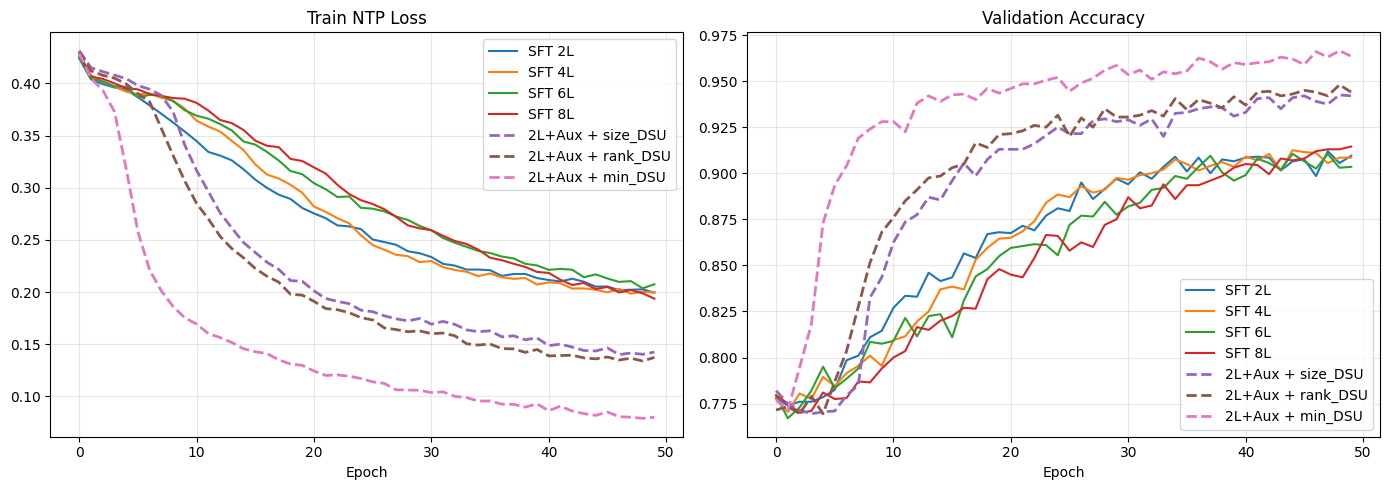

In [11]:
import json
import matplotlib.pyplot as plt

def plot_training_log(log_path, label):
    with open(log_path) as f:
        log = json.load(f)
    epochs = [e["epoch"] for e in log]
    return log

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: train loss
ax = axes[0]
for nl in [2, 4, 6, 8]:
    log = plot_training_log(f"checkpoints/graph_sft_{nl}L/train_log.json", f"SFT {nl}L")
    ax.plot([e["epoch"] for e in log], [e["train"]["loss"] for e in log], label=f"SFT {nl}L")

for DSU_type in ["size", "rank", "min"]:
    log = plot_training_log(f"checkpoints/graph_aux_2L_{DSU_type}/train_log.json", f"2L+Aux + {DSU_type}_DSU")
    ax.plot([e["epoch"] for e in log], [e["train"]["loss_lm"] for e in log], label=f"2L+Aux + {DSU_type}_DSU", linewidth=2, linestyle="--")

ax.set_xlabel("Epoch"); ax.set_title("Train NTP Loss");
# ax.set_ylabel("Train NTP Loss"); 

ax.legend(); ax.grid(True, alpha=0.3)


# Right: val accuracy
ax = axes[1]
for nl in [2, 4, 6, 8]:
    log = plot_training_log(f"checkpoints/graph_sft_{nl}L/train_log.json", f"SFT {nl}L")
    ax.plot([e["epoch"] for e in log], [e["val"]["accuracy"] for e in log], label=f"SFT {nl}L")

for DSU_type in ["size", "rank", "min"]:
    
    log = plot_training_log(f"checkpoints/graph_aux_2L_{DSU_type}/train_log.json", f"2L+Aux + {DSU_type}_DSU")
    ax.plot([e["epoch"] for e in log], [e["val"]["accuracy"] for e in log], label=f"2L+Aux + {DSU_type}_DSU", linewidth=2, linestyle="--")

ax.set_xlabel("Epoch");  ax.set_title("Validation Accuracy"); 
# ax.set_ylabel("Val Accuracy")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curves_depth.png", dpi=150)
plt.show()

## 6. Сравнительная таблица результатов

In [12]:
import pandas as pd

rows = []
for name, results in all_eval.items():
    row = {"Model": name}
    for split_name, metrics in results.items():
        row[f"{split_name} acc"] = f"{metrics['accuracy']:.1%}"
    rows.append(row)
df = pd.DataFrame(rows)
print(df.to_string(index=False))

               Model test_id acc test_ood_2chain acc test_ood_2clique acc test_ood_adversarial acc test_ood_cyclic_grid acc test_ood_large_n acc
              SFT 2L       91.3%               50.1%                47.6%                    53.0%                   100.0%                71.5%
              SFT 4L       91.4%               51.1%                47.6%                    50.9%                   100.0%                72.6%
              SFT 6L       90.8%               50.0%                47.6%                    63.7%                   100.0%                71.3%
              SFT 8L       91.9%               50.0%                47.6%                    53.7%                   100.0%                70.8%
2L+Aux Loss+size_DSU       94.4%               51.2%                47.0%                    56.0%                   100.0%                72.1%
2L+Aux Loss+rank_DSU       94.6%               52.0%                47.6%                    58.4%                   100.0%       

## 6a. Accuracy by Distance (test_id)

Ключевой график: accuracy модели в зависимости от shortest-path distance между query вершинами.

**Ожидание:**
- SFT: обвал на distance > ~4 (capacity bottleneck)
- 2L + Aux Loss: 100% на всех distance

Distance = -1 означает unreachable пары (разные компоненты).

SFT 2L:
  dist= -1: acc=71.5% (n=1144)
  dist=  1: acc=98.5% (n=1296)
  dist=  2: acc=97.5% (n=1103)
  dist=  3: acc=95.7% (n=672)
  dist=  4: acc=96.7% (n=366)
  dist=  5: acc=94.6% (n=168)
  dist=  6: acc=93.2% (n=103)
  dist=  7: acc=94.8% (n=58)
  dist=  8: acc=100.0% (n=37)
  dist=  9: acc=100.0% (n=18)
  dist= 10: acc=100.0% (n=9)
  dist= 11: acc=100.0% (n=4)
  dist= 12: acc=100.0% (n=6)
  dist= 13: acc=100.0% (n=3)
  dist= 14: acc=100.0% (n=4)
  dist= 15: acc=100.0% (n=2)
  dist= 16: acc=100.0% (n=1)
  dist= 17: acc=100.0% (n=4)
  dist= 19: acc=100.0% (n=2)
SFT 4L:
  dist= -1: acc=65.1% (n=1144)
  dist=  1: acc=99.5% (n=1296)
  dist=  2: acc=99.2% (n=1103)
  dist=  3: acc=98.8% (n=672)
  dist=  4: acc=98.4% (n=366)
  dist=  5: acc=98.8% (n=168)
  dist=  6: acc=100.0% (n=103)
  dist=  7: acc=100.0% (n=58)
  dist=  8: acc=100.0% (n=37)
  dist=  9: acc=100.0% (n=18)
  dist= 10: acc=100.0% (n=9)
  dist= 11: acc=100.0% (n=4)
  dist= 12: acc=100.0% (n=6)
  dist= 13: acc=100.0% (n=3)
 

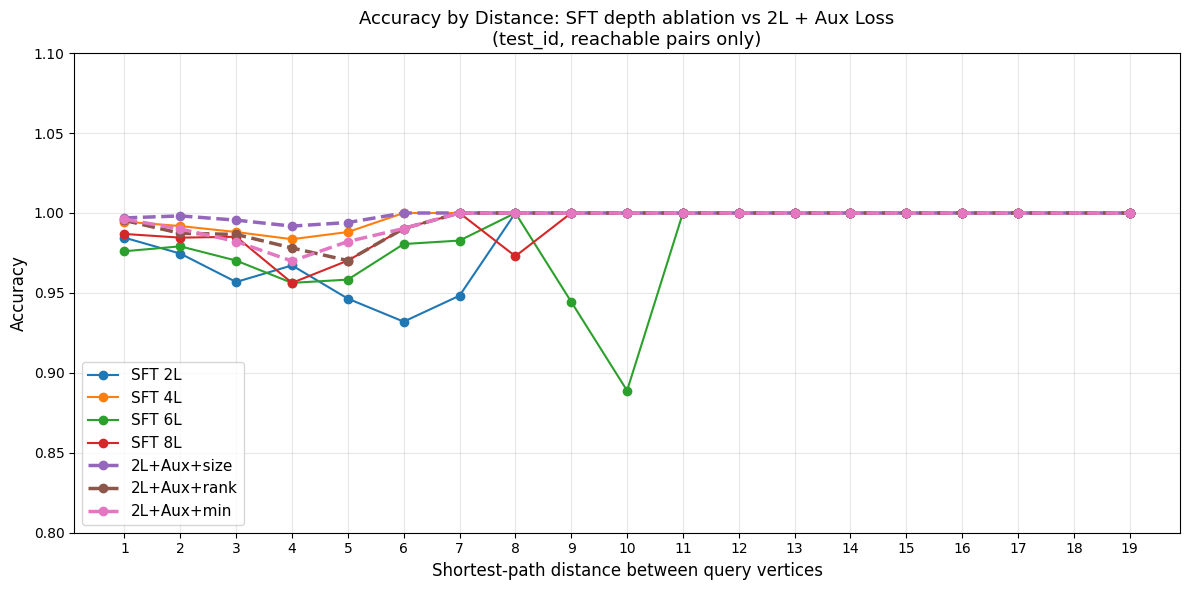

Saved accuracy_by_distance.png


In [13]:
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from collections import defaultdict
from graph_connectivity.src.model import GraphGPT, DSUProbe
from graph_connectivity.src.tokenizer import GraphTokenizer, PAD_ID
from graph_connectivity.src.data import GraphConnectivityDataset, collate_fn
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = GraphTokenizer(max_n=30)
MAX_N = 30


def load_ckpt(path, n_layer, lam=0.0):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    m = GraphGPT(tokenizer.vocab_size, 256, n_layer, 4, 128, 0.0, MAX_N).to(device)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    return m


@torch.no_grad()
def accuracy_by_distance(model, test_json_path):
    """Compute accuracy grouped by shortest-path distance."""
    with open(test_json_path) as f:
        data = json.load(f)

    ds = GraphConnectivityDataset(test_json_path, tokenizer, max_n=MAX_N, fixed=True)
    loader = DataLoader(ds, batch_size=64, shuffle=False, collate_fn=collate_fn)

    # Collect predictions
    all_preds = []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attn_mask = input_ids != PAD_ID
        hidden, _ = model(input_ids, attn_mask)
        B = input_ids.size(0)
        ans_pos = batch["ans_pos"].to(device)
        ans_hidden = hidden[torch.arange(B, device=device), ans_pos]
        logits = model.classifier(ans_hidden)
        preds = logits.argmax(dim=-1).cpu().tolist()
        all_preds.extend(preds)

    # Group by distance
    dist_correct = defaultdict(list)
    for i, example in enumerate(data):
        if i >= len(all_preds):
            break
        dist = example.get("distance", -1)
        label = example["label"]
        pred = all_preds[i]
        dist_correct[dist].append(int(pred == label))

    result = {}
    for dist in sorted(dist_correct.keys()):
        vals = dist_correct[dist]
        result[dist] = {"accuracy": np.mean(vals), "count": len(vals)}
    return result


# Load models
models = {}
for nl in [2, 4, 6, 8]:
    models[f"SFT {nl}L"] = load_ckpt(f"checkpoints/graph_sft_{nl}L/checkpoint_best.pt", nl)

for DSU_type in ["size", "rank", "min"]:
    models[f"2L+Aux+{DSU_type}"] = load_ckpt(f"checkpoints/graph_aux_2L_{DSU_type}/checkpoint_best.pt", 2)

# Compute accuracy by distance for test_id
test_path = "graph_connectivity/data/test_id.json"
all_by_dist = {}
for name, model in models.items():
    all_by_dist[name] = accuracy_by_distance(model, test_path)
    dists = sorted(all_by_dist[name].keys())
    print(f"{name}:")
    for d in dists:
        r = all_by_dist[name][d]
        print(f"  dist={d:>3d}: acc={r['accuracy']:.1%} (n={r['count']})")

# ── Plot ──
fig, ax = plt.subplots(figsize=(12, 6))

# Only plot positive distances (reachable pairs)
for name, by_dist in all_by_dist.items():
    dists = sorted([d for d in by_dist.keys() if d > 0])
    accs = [by_dist[d]["accuracy"] for d in dists]
    style = "--" if "Aux" in name else "-"
    lw = 2.5 if "Aux" in name else 1.5
    ax.plot(dists, accs, style, linewidth=lw, marker="o", label=name, markersize=6)

ax.set_xlabel("Shortest-path distance between query vertices", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Accuracy by Distance: SFT depth ablation vs 2L + Aux Loss\n"
             "(test_id, reachable pairs only)", fontsize=13)
ax.set_ylim(0.8, 1.1)

ax.set_xticks(range(1, max(max(d for d in v.keys() if d > 0) for v in all_by_dist.values()) + 1))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5, label="random")
plt.tight_layout()
plt.savefig("accuracy_by_distance.png", dpi=150)
plt.show()
print("Saved accuracy_by_distance.png")

## 6b. OOD Results: 2Chain + 2Clique

**2chain** — две длинные разъединённые цепочки. Тестирует capacity bottleneck:
SFT не может проследить длинный путь.

**2clique** — две полных клики без связи. Тестирует degree shortcut (Qilin Ye et al.):
SFT видит высокую степень → предсказывает "connected" даже между кликами.

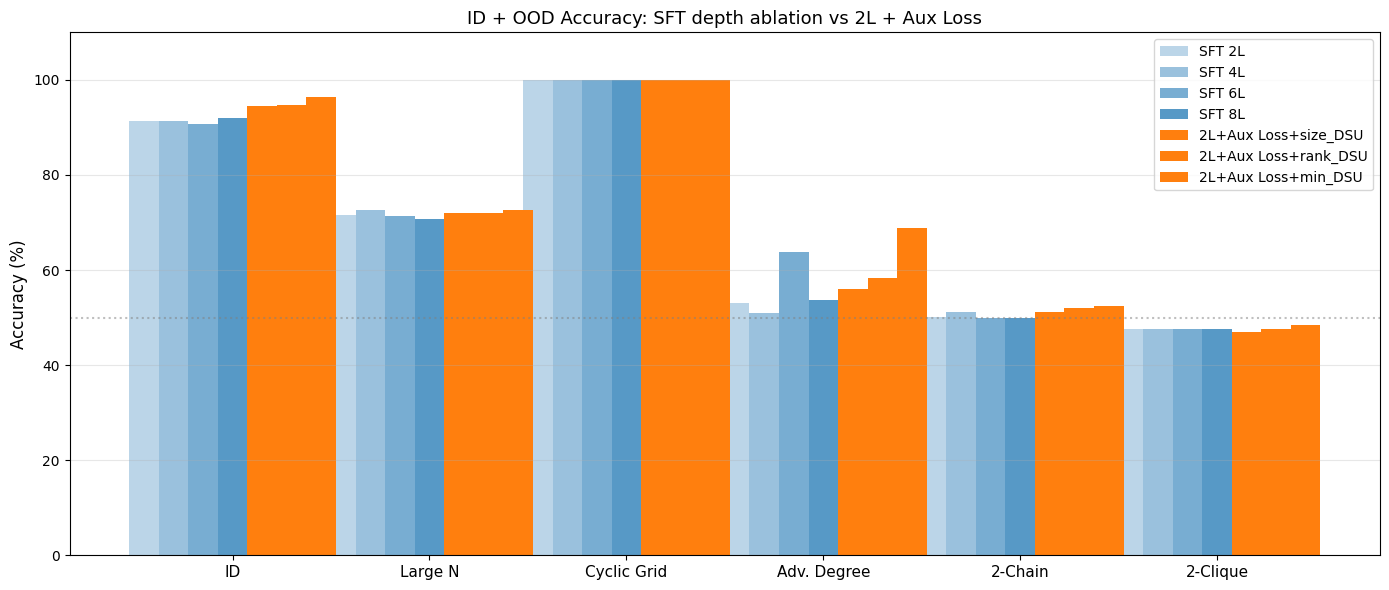

Saved ood_accuracy_comparison.png


In [14]:
# OOD accuracy comparison: grouped bar chart

ood_sets = ["test_id", "test_ood_large_n", "test_ood_cyclic_grid",
            "test_ood_adversarial", "test_ood_2chain", "test_ood_2clique"]
ood_labels = ["ID", "Large N", "Cyclic Grid", "Adv. Degree", "2-Chain", "2-Clique"]

# model_names = ["SFT 2L", "SFT 4L", "SFT 6L", "SFT 8L", "2L + Aux Loss"]
model_names = list(all_eval.keys())

# all_eval was computed in cell 13
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(ood_labels))
n_models = len(model_names)
width = 0.15

for i, mname in enumerate(model_names):
    accs = []
    for ood_name in ood_sets:
        if mname in all_eval and ood_name in all_eval[mname]:
            accs.append(all_eval[mname][ood_name]["accuracy"])
        else:
            accs.append(0.0)
    color = "C1" if "Aux" in mname else "C0"
    alpha = 1.0 if "Aux" in mname else 0.3 + 0.15 * i
    bars = ax.bar(x + i * width - (n_models-1)*width/2, [a*100 for a in accs],
                  width, label=mname, color=color, alpha=alpha)

ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("ID + OOD Accuracy: SFT depth ablation vs 2L + Aux Loss", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(ood_labels, fontsize=11)
ax.set_ylim(0, 110)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
ax.axhline(y=50, color="gray", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("ood_accuracy_comparison.png", dpi=150)
plt.show()
print("Saved ood_accuracy_comparison.png")

## 6c. Accuracy on Unreachable Pairs (distance = -1)

Отдельно показываем accuracy на парах из **разных компонент** (label=0).
На 2clique SFT должен показать ~0% (всегда предсказывает "connected" из-за высокой degree).

In [15]:
# Accuracy on unreachable pairs for each OOD set
ood_files = {
    "2-Chain": "graph_connectivity/data/test_ood_2chain.json",
    "2-Clique": "graph_connectivity/data/test_ood_2clique.json",
}

print(f"{'Model':>15s}  {'2-Chain (unreach)':>18s}  {'2-Clique (unreach)':>18s}")
print("-" * 55)

for mname, model in models.items():
    row = f"{mname:>15s}"
    for ood_label, ood_path in ood_files.items():
        by_dist = accuracy_by_distance(model, ood_path)
        if -1 in by_dist:
            acc = by_dist[-1]["accuracy"]
            n = by_dist[-1]["count"]
            row += f"  {acc:>6.1%} (n={n:>4d})"
        else:
            row += f"  {'N/A':>16s}"
    print(row)

          Model   2-Chain (unreach)  2-Clique (unreach)
-------------------------------------------------------
         SFT 2L    3.5% (n= 488)    0.0% (n= 524)
         SFT 4L    3.9% (n= 488)    0.0% (n= 524)
         SFT 6L    7.2% (n= 488)    0.0% (n= 524)
         SFT 8L    2.5% (n= 488)    0.0% (n= 524)
    2L+Aux+size    0.0% (n= 488)    5.3% (n= 524)
    2L+Aux+rank    4.1% (n= 488)    0.0% (n= 524)
     2L+Aux+min    9.0% (n= 488)   10.1% (n= 524)


## 7. Анализ скрытых состояний (по мотивам Bai et al., 2025)

Воспроизводим ключевые анализы из статьи "Why Can't Transformers Learn Multiplication?" адаптированные для задачи graph connectivity:

| Анализ | Статья (multiplication) | Наша адаптация (graph connectivity) |
|--------|------------------------|-------------------------------------|
| **Figure 3** — Linear Probing | Probe для $\hat{c}_k$ (running sum) из $h^{(L,\mathrm{mid})}$ | Probe для $\mathrm{comp}[v]$ (DSU state) из hidden states каждого слоя |
| **Figure 2** — Logit Attribution | Замена цифры → Δ logit | Маскирование ребра → Δ logit |
| **Figures 4,8,10** — Attention | Heatmaps по слоям/головам | То же |
| **Figures 5,6** — PCA | PCA hidden states + Fourier basis | PCA edge positions + ⟨ANS⟩ position |
| **Figure 7** — Per-token dynamics | Grad norm + loss per $c_k$ | DSU accuracy per edge position |

In [16]:
# ── Setup: load models, extract hidden states from validation set ──

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA as SklearnPCA

from graph_connectivity.src.model import GraphGPT, DSUProbe
from graph_connectivity.src.tokenizer import GraphTokenizer, PAD_ID
from graph_connectivity.src.data import GraphConnectivityDataset, collate_fn
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = GraphTokenizer(max_n=30)
MAX_N = 30


@torch.no_grad()
def extract_states(model, input_ids, attn_mask):
    """Manual forward pass — collect hidden states + attention weights at every layer."""
    B, T = input_ids.shape
    pos = torch.arange(T, device=input_ids.device).unsqueeze(0)
    x = model.token_emb(input_ids) + model.pos_emb(pos)

    layer_hiddens = [x.cpu()]       # 0 = after embedding
    mid_hiddens = []                # after attn + residual, before MLP
    attn_weights = []               # attention probs [B, H, T, T]
    head_outputs = []               # attention outputs [B, H, T, d_head]

    for block in model.blocks:
        x_ln = block.ln1(x)
        attn = block.attn
        Bx, Tx, Cx = x_ln.shape
        qkv = attn.qkv(x_ln).reshape(Bx, Tx, 3, attn.n_head, attn.d_head)
        q, k, v = [t.transpose(1, 2) for t in qkv.unbind(2)]

        scores = (q @ k.transpose(-2, -1)) / attn.d_head ** 0.5
        causal = torch.triu(torch.ones(Tx, Tx, device=x.device, dtype=torch.bool), 1)
        scores.masked_fill_(causal[None, None], float("-inf"))
        if attn_mask is not None:
            scores.masked_fill_(~attn_mask[:, None, None, :], float("-inf"))

        probs = scores.softmax(-1)
        a_out = probs @ v

        attn_weights.append(probs.cpu())
        head_outputs.append(a_out.cpu())

        proj = attn.out_proj(a_out.transpose(1, 2).reshape(Bx, Tx, -1))
        x = x + proj
        mid_hiddens.append(x.cpu())
        x = x + block.mlp(block.ln2(x))
        layer_hiddens.append(x.cpu())       # l+1 = after block l

    layer_hiddens.append(model.ln_f(x).cpu())  # final LN
    return dict(layer_hiddens=layer_hiddens, mid_hiddens=mid_hiddens,
                attn_weights=attn_weights, head_outputs=head_outputs)


def load_model_from_ckpt(path, n_layer, lam=0.0):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    m = GraphGPT(tokenizer.vocab_size, 256, n_layer, 4, 128, 0.0, MAX_N).to(device)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    p = None
    if lam > 0 and "probe_state_dict" in ckpt:
        d_head = 256 // 4
        p = DSUProbe(4, d_head, MAX_N).to(device)
        p.load_state_dict(ckpt["probe_state_dict"])
        p.eval()
    return m, p


# Load all models
sft_models = {}
aux_models = {}
aux_probes = {}
for nl in [2, 4, 6, 8]:
    path = f"checkpoints/graph_sft_{nl}L/checkpoint_best.pt"
    sft_models[nl], _ = load_model_from_ckpt(path, n_layer=nl, lam=0.0)
    print(f"Loaded SFT {nl}L")

for DSU_type in ["size", "rank", "min"]:
    
    # aux_model, aux_probe = load_model_from_ckpt(
    aux_models[DSU_type], aux_probes[DSU_type] = load_model_from_ckpt(
        f"checkpoints/graph_aux_2L_{DSU_type}/checkpoint_best.pt", n_layer=2, lam=10.0)
    
    print(f"Loaded 2L + Aux Loss + {DSU_type}")

# Load validation data
val_ds = GraphConnectivityDataset(
    "graph_connectivity/data/val.json", tokenizer, max_n=MAX_N, fixed=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)

N_ANALYSIS = 8  # batches ~ 512 examples


def collect(model, loader, n):
    S, B = [], []
    for i, batch in enumerate(loader):
        if i >= n:
            break
        ids = batch["input_ids"].to(device)
        S.append(extract_states(model, ids, ids != PAD_ID))
        B.append(batch)
    return S, B


# Extract states for all models
all_model_states = {}
for nl in [2, 4, 6, 8]:
    print(f"Extracting SFT {nl}L hidden states ...")
    all_model_states[f"SFT {nl}L"], val_batches = collect(sft_models[nl], val_loader, N_ANALYSIS)

for DSU_type in ["size", "rank", "min"]:
    
    print(f"Extracting 2L+Aux+{DSU_type} hidden states ...")
    
    all_model_states[f"2L+Aux+{DSU_type}"], _ = collect(aux_models[DSU_type], val_loader, N_ANALYSIS)

print(f"Done — {N_ANALYSIS * 64} examples")

Loaded SFT 2L
Loaded SFT 4L
Loaded SFT 6L
Loaded SFT 8L
Loaded 2L + Aux Loss + size
Loaded 2L + Aux Loss + rank
Loaded 2L + Aux Loss + min
Extracting SFT 2L hidden states ...
Extracting SFT 4L hidden states ...
Extracting SFT 6L hidden states ...
Extracting SFT 8L hidden states ...
Extracting 2L+Aux+size hidden states ...
Extracting 2L+Aux+rank hidden states ...
Extracting 2L+Aux+min hidden states ...
Done — 512 examples


### 7.1 Linear Probing: comp[] из скрытых состояний

Для каждой модели обучаем линейный probe на hidden states последнего слоя.
Сравниваем: **SFT 2L/4L/6L/8L vs 2L+Aux**.

Если 2L+Aux >> 8L SFT — auxiliary loss заставляет модель явно представлять DSU state,
чего дополнительная глубина не даёт.

          Model      Emb     Last       LN
---------------------------------------------
         SFT 2L    0.732    0.846    0.841
         SFT 4L    0.733    0.855    0.852
         SFT 6L    0.732    0.842    0.840
         SFT 8L    0.732    0.842    0.840
    2L+Aux+size    0.733    0.919    0.913
    2L+Aux+rank    0.732    0.921    0.921
     2L+Aux+min    0.732    0.961    0.964


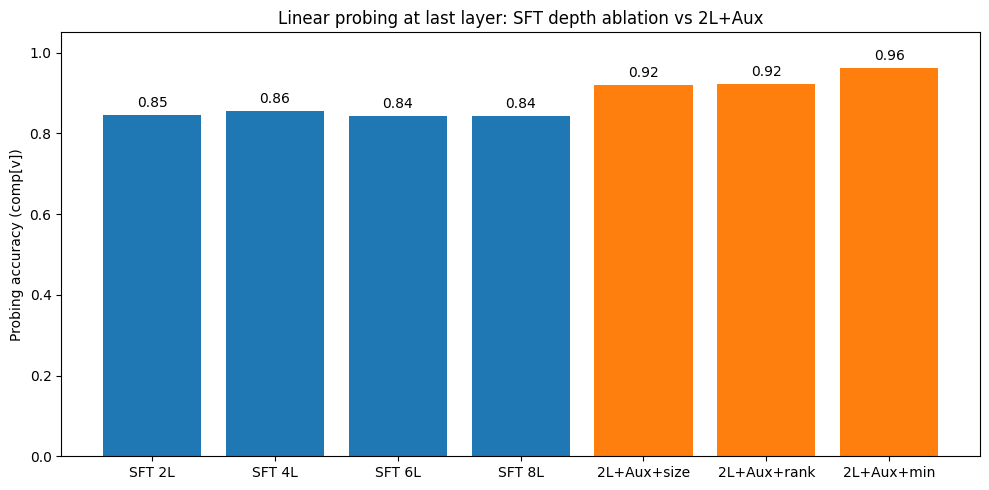

In [17]:
# Linear probing: predict comp[v] from hidden states — SFT depth ablation vs 2L+Aux
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

PROBE_VERTICES = [0, 3, 7, 12, 19]

def gather_probing_data(all_states, batches, layer_idx):
    """Collect hidden states at edge positions + comp targets per vertex."""
    Xv = {v: [] for v in PROBE_VERTICES}
    yv = {v: [] for v in PROBE_VERTICES}
    for states, batch in zip(all_states, batches):
        h = states["layer_hiddens"][layer_idx]
        for b in range(h.size(0)):
            m = batch["num_edges"][b].item()
            n_v = int(batch["vertex_mask"][b].sum().item())
            if m == 0:
                continue
            eh = h[b, 1:m + 1].numpy()
            for v in PROBE_VERTICES:
                if v < n_v:
                    Xv[v].append(eh)
                    yv[v].append(batch["comp_states"][b, :m, v].numpy())
    return Xv, yv


def probe_accuracy(all_states, batches, layer_idx, max_n=8000):
    Xv, yv = gather_probing_data(all_states, batches, layer_idx)
    accs = []
    for v in PROBE_VERTICES:
        if not Xv[v]:
            continue
        X = np.concatenate(Xv[v])
        y = np.concatenate(yv[v])
        if len(np.unique(y)) < 2:
            accs.append(1.0)
            continue
        if len(X) > max_n:
            idx = np.random.RandomState(42).choice(len(X), max_n, replace=False)
            X, y = X[idx], y[idx]
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42)
        # clf = LogisticRegression(max_iter=5000, C=1.0, solver="lbfgs", random_state=42)
        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs", random_state=42)
        )
        clf.fit(Xtr, ytr)
        accs.append(clf.score(Xte, yte))
    return float(np.mean(accs))


# ── Probing at LAST layer for each model ──
# For each model, probe at embedding (0), last layer, and final LN
print(f"{'Model':>15s}   {'Emb':>6s}   {'Last':>6s}   {'LN':>6s}")
print("-" * 45)

probe_results = {}
for model_name, states in all_model_states.items():
    n_layers = len(states[0]["layer_hiddens"]) - 2  # minus emb and final LN
    emb_acc = probe_accuracy(states, val_batches, 0)
    last_acc = probe_accuracy(states, val_batches, n_layers)  # last transformer layer
    ln_acc = probe_accuracy(states, val_batches, n_layers + 1)  # final LN
    probe_results[model_name] = {"emb": emb_acc, "last": last_acc, "ln": ln_acc}
    print(f"{model_name:>15s}   {emb_acc:>6.3f}   {last_acc:>6.3f}   {ln_acc:>6.3f}")

# ── Bar chart: probing accuracy at last layer ──
fig, ax = plt.subplots(figsize=(10, 5))
names = list(probe_results.keys())
last_accs = [probe_results[n]["last"] for n in names]
colors = ["C0"] * 4 + ["C1"] * 3  # blue for SFT, orange for Aux
bars = ax.bar(names, last_accs, color=colors)
ax.set_ylabel("Probing accuracy (comp[v])")
ax.set_ylim(0, 1.05)
ax.set_title("Linear probing at last layer: SFT depth ablation vs 2L+Aux")
for bar, acc in zip(bars, last_accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.02, f"{acc:.2f}",
            ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("probing_depth_ablation.png", dpi=150)
plt.show()

In [18]:
10

10

### 7.2 Визуализация Attention Patterns (аналог Figures 4, 8, 10)

Heatmaps attention weights для каждого слоя и головы. Ожидаемые различия:
- **SFT**: нет явной структуры в attention к рёбрам
- **Aux Loss**: внимание более структурировано — головы могут специализироваться на отслеживании компонент связности

Example: 8 edges, label=0
S E(0,5) E(3,7) E(4,7) E(1,5) E(0,7) E(1,4) E(0,6) E(5,7) | Q(3,2) A 0 E


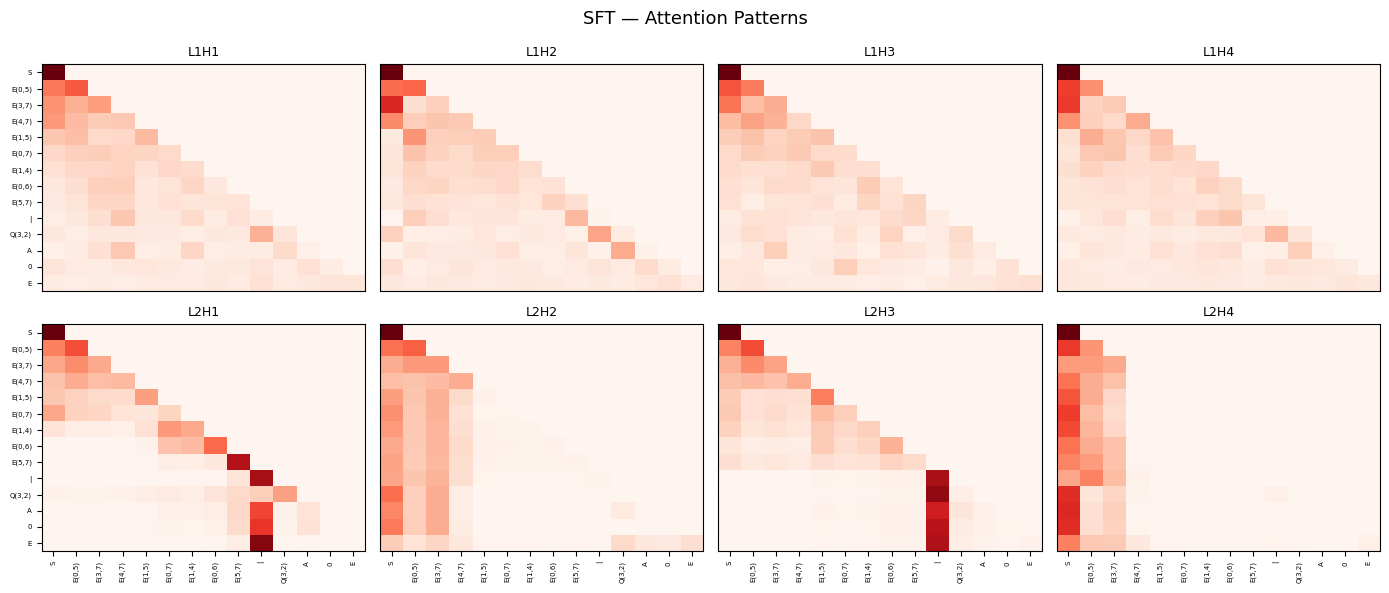

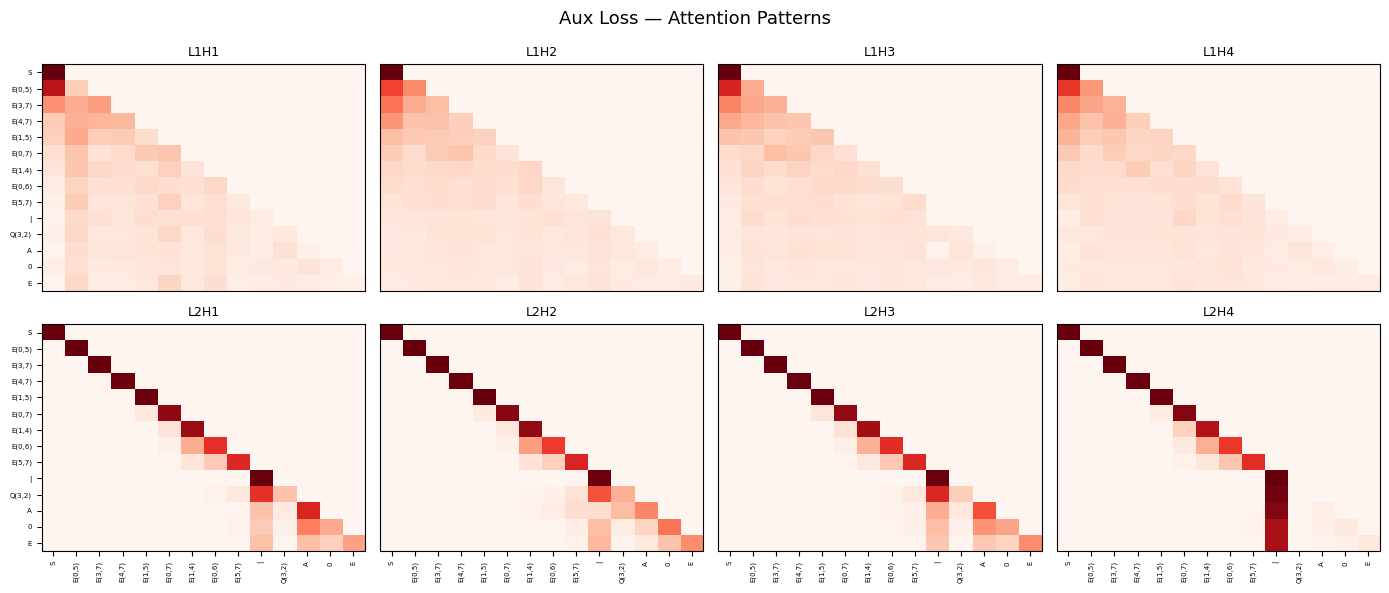

In [19]:
# Attention pattern heatmaps for a single example (both models)

# Pick a medium-sized example (8–15 edges)
first_batch = val_batches[0]
ex_b = next(b for b in range(first_batch["input_ids"].size(0))
            if 8 <= first_batch["num_edges"][b].item() <= 15)

ex_ids = first_batch["input_ids"][ex_b:ex_b + 1].to(device)
ex_mask = (ex_ids != PAD_ID)
ex_m = first_batch["num_edges"][ex_b].item()
ex_label = first_batch["targets"][ex_b].item()

ex_sft = extract_states(sft_models[2], ex_ids, ex_mask)
ex_aux = extract_states(aux_models["min"], ex_ids, ex_mask)

# Token labels
raw = first_batch["input_ids"][ex_b].tolist()
tok_labels = []
for tid in raw:
    t = tokenizer.id2token.get(tid, "?")
    for old, new in [("<START>", "S"), ("<SEP>", "|"), ("<ANS>", "A"),
                     ("<END>", "E"), ("<PAD>", ".")]:
        t = t.replace(old, new)
    tok_labels.append(t)
seq_len = int(ex_mask.sum().item())

print(f"Example: {ex_m} edges, label={ex_label}")
print(" ".join(tok_labels[:seq_len]))


def plot_attn_grid(attn_list, title, labels, sl):
    n_layers = len(attn_list)
    n_heads = attn_list[0].size(1)
    fig, axes = plt.subplots(n_layers, n_heads, figsize=(3.5 * n_heads, 3 * n_layers))
    for l in range(n_layers):
        for hh in range(n_heads):
            ax = axes[l, hh]
            w = attn_list[l][0, hh, :sl, :sl].numpy()
            ax.imshow(w, cmap="Reds", vmin=0, aspect="auto")
            ax.set_title(f"L{l+1}H{hh+1}", fontsize=9)
            if hh == 0:
                ax.set_yticks(range(sl))
                ax.set_yticklabels(labels[:sl], fontsize=5)
            else:
                ax.set_yticks([])
            if l == n_layers - 1:
                ax.set_xticks(range(sl))
                ax.set_xticklabels(labels[:sl], fontsize=5, rotation=90)
            else:
                ax.set_xticks([])
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    return fig


fig1 = plot_attn_grid(ex_sft["attn_weights"], "SFT — Attention Patterns",
                      tok_labels, seq_len)
fig1.savefig("attention_sft.png", dpi=150, bbox_inches="tight")

fig2 = plot_attn_grid(ex_aux["attn_weights"], "Aux Loss — Attention Patterns",
                      tok_labels, seq_len)
fig2.savefig("attention_aux.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.3 PCA скрытых состояний (аналог Figures 5-6)

**Верхний ряд:** PCA hidden states на позициях рёбер (final layer), цвет = относительная позиция ребра (0 = первое, 1 = последнее). Показывает, как модель организует представления по ходу обработки рёбер.

**Нижний ряд:** PCA hidden states на позиции `<ANS>`, цвет = label (connected/disconnected). Показывает, насколько чётко модель разделяет классы.

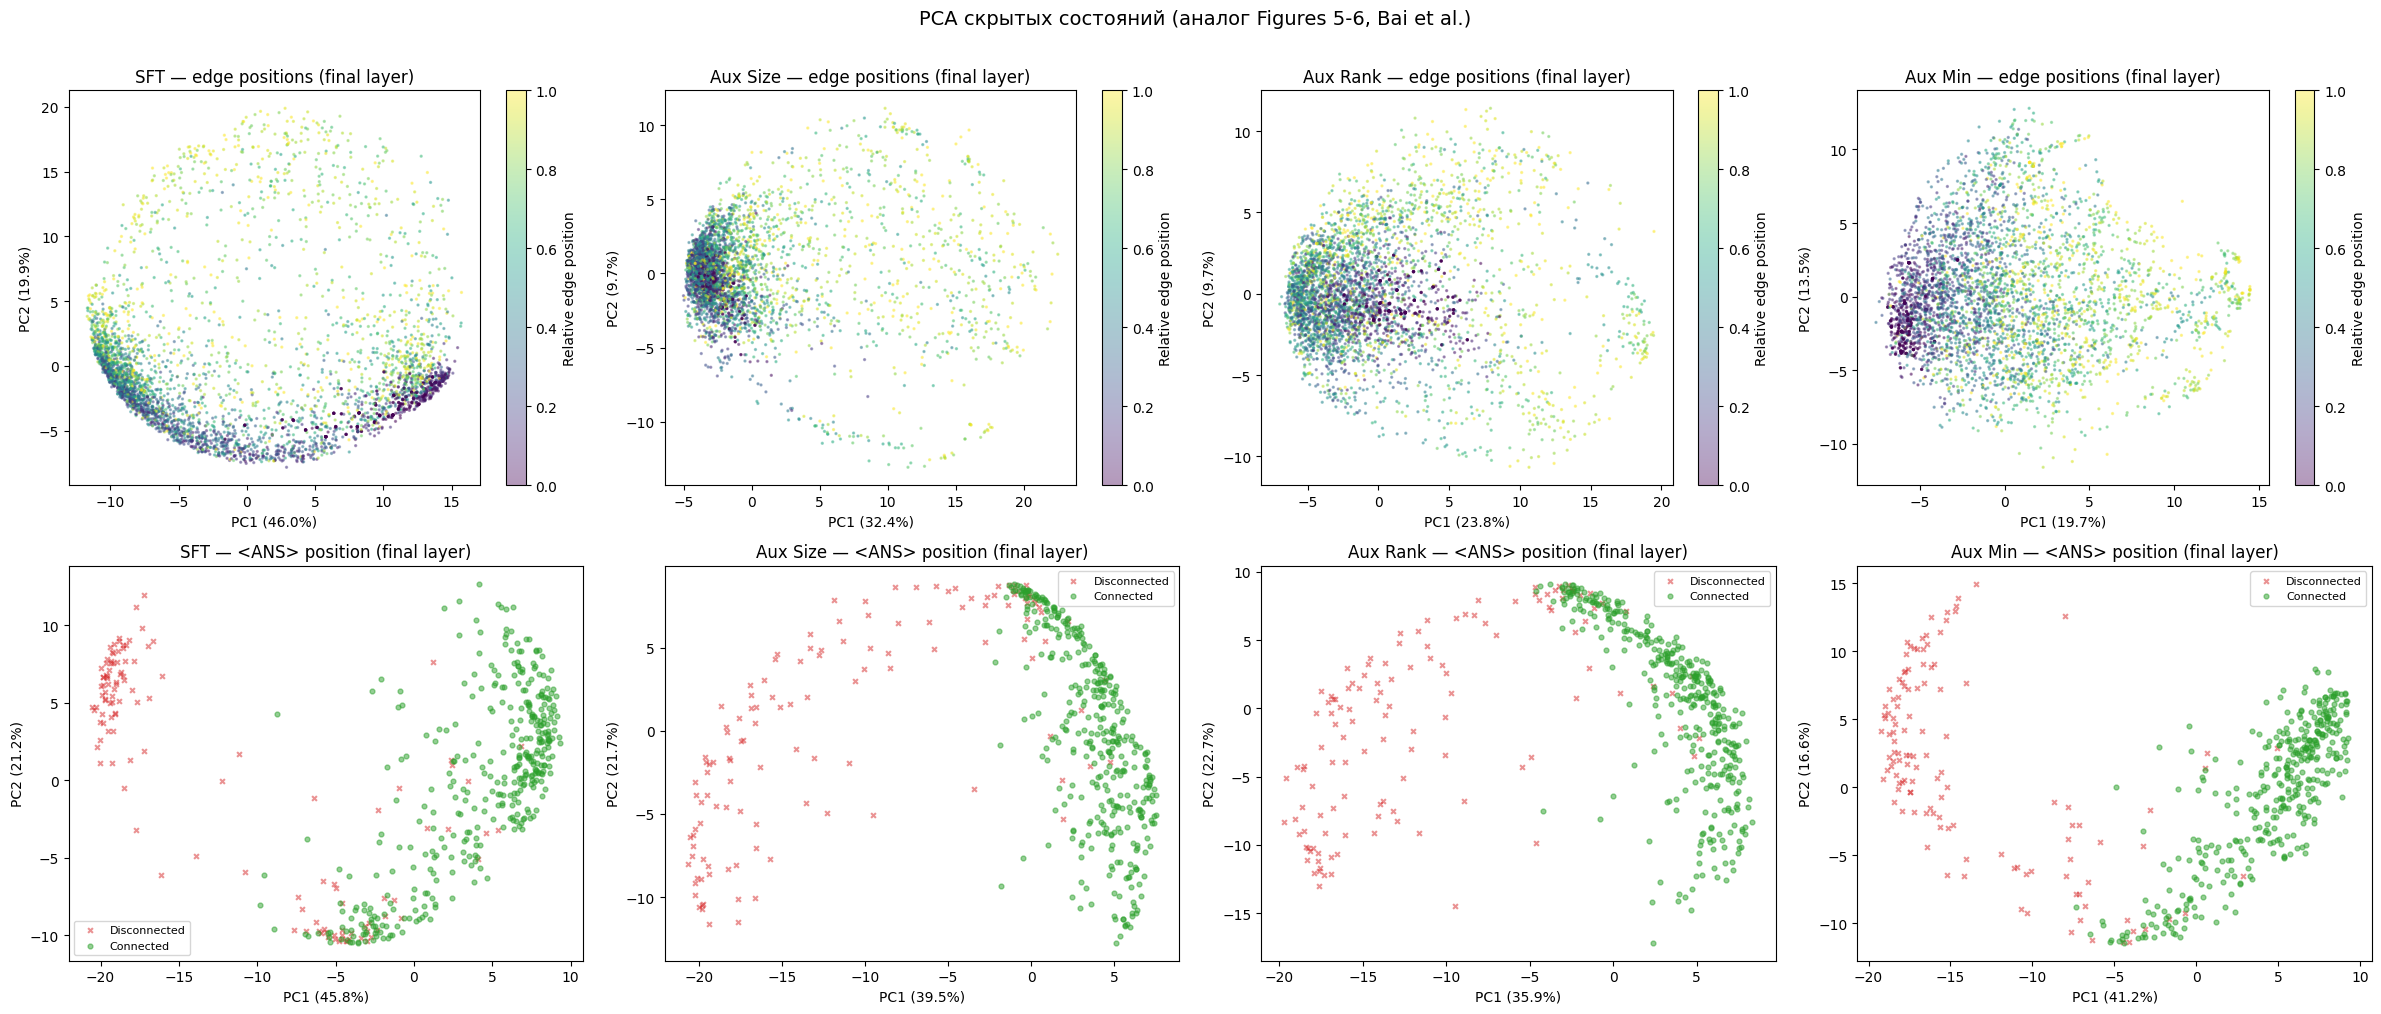

In [20]:
# PCA of hidden states

def gather_at_positions(all_states, batches, li, mode="edge"):
    """Gather hidden states at edge or <ANS> positions."""
    H, L = [], []
    for states, batch in zip(all_states, batches):
        h = states["layer_hiddens"][li]
        for b in range(h.size(0)):
            m = batch["num_edges"][b].item()
            if mode == "edge" and m > 0:
                H.append(h[b, 1:m + 1].numpy())
                L.extend(np.linspace(0, 1, m).tolist())
            elif mode == "ans":
                ap = batch["ans_pos"][b].item()
                H.append(h[b, ap:ap + 1].numpy())
                L.append(batch["targets"][b].item())
    return np.concatenate(H), np.array(L)

fig, axes = plt.subplots(2, 4, figsize=(24, 10))

for col, (name, st) in enumerate([("SFT", all_model_states["SFT 2L"]), ("Aux Size", all_model_states["2L+Aux+size"]), ("Aux Rank", all_model_states["2L+Aux+rank"]), ("Aux Min", all_model_states["2L+Aux+min"])]):
    # Row 0: edge positions, final layer — colored by relative position
    X, c = gather_at_positions(st, val_batches, -1, "edge")
    n_plot = min(4000, len(X))
    pca = SklearnPCA(2)
    Z = pca.fit_transform(X[:n_plot])
    c = c[:n_plot]
    ax = axes[0, col]
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=c, cmap="viridis", s=2, alpha=0.4)
    ax.set_title(f"{name} — edge positions (final layer)")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    plt.colorbar(sc, ax=ax, label="Relative edge position")

    # Row 1: <ANS> position — colored by label
    Xa, la = gather_at_positions(st, val_batches, -1, "ans")
    pca2 = SklearnPCA(2)
    Za = pca2.fit_transform(Xa)
    ax = axes[1, col]
    for lb, clr, mk in [(0, "C3", "x"), (1, "C2", "o")]:
        mask = la == lb
        ax.scatter(Za[mask, 0], Za[mask, 1], c=clr, s=12, alpha=0.5,
                   label="Disconnected" if lb == 0 else "Connected", marker=mk)
    ax.set_title(f"{name} — <ANS> position (final layer)")
    ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
    ax.legend(fontsize=8)

plt.suptitle("PCA скрытых состояний (аналог Figures 5-6, Bai et al.)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("pca_hidden_states.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.4 DSU state accuracy по позиции ребра (аналог Figure 7)

Используем обученный DSUProbe модели Aux Loss для измерения accuracy предсказания `comp[]` на каждой позиции ребра. Показывает, одинаково ли хорошо модель отслеживает состояние DSU для ранних и поздних рёбер.

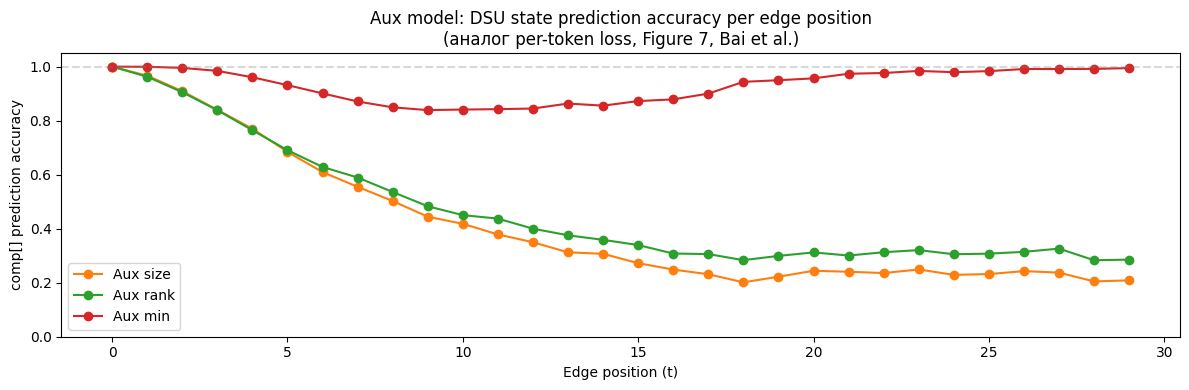

size Mean accuracy (first 10 edges):  0.728
size Mean accuracy (edges 10-19):     0.294
rank Mean accuracy (first 10 edges):  0.740
rank Mean accuracy (edges 10-19):     0.356
min Mean accuracy (first 10 edges):  0.933
min Mean accuracy (edges 10-19):     0.879


In [21]:
# Per-edge-position DSU state accuracy (Aux model with trained probe)

@torch.no_grad()
def per_position_accuracy(model, probe, loader, n_batches=8):
    """DSU comp[] prediction accuracy at each edge position."""
    pos_correct = {}
    pos_total = {}
    for i, batch in enumerate(loader):
        if i >= n_batches:
            break
        ids = batch["input_ids"].to(device)
        _, lho = model(ids, ids != PAD_ID)
        cs = batch["comp_states"].to(device)
        vm = batch["vertex_mask"].to(device)
        M = cs.size(1)
        if M == 0 or probe is None:
            continue
        epos = torch.arange(1, M + 1, device=device)
        eho = lho[:, :, epos, :]
        logits = probe(eho).mean(dim=1)   # avg over heads → [B, M, N, N]
        preds = logits.argmax(-1)          # [B, M, N]
        for b in range(ids.size(0)):
            m = batch["num_edges"][b].item()
            nv = int(vm[b].sum().item())
            for t in range(m):
                c = (preds[b, t, :nv] == cs[b, t, :nv]).sum().item()
                pos_correct[t] = pos_correct.get(t, 0) + c
                pos_total[t] = pos_total.get(t, 0) + nv
    positions = sorted(pos_correct)
    accs = [pos_correct[t] / pos_total[t] for t in positions]
    return positions, accs

positions_all = {}
accs_all = {}
for DSU_type in ["size", "rank", "min"]:
    positions_all[DSU_type], accs_all[DSU_type] = per_position_accuracy(aux_models[DSU_type], aux_probes[DSU_type], val_loader, N_ANALYSIS)

fig, ax = plt.subplots(figsize=(12, 4))
for i, DSU_type in enumerate(["size", "rank", "min"]):
    ax.plot(positions_all[DSU_type][:30], accs_all[DSU_type][:30], label=f"Aux {DSU_type}", color=f"C{i+1}", marker="o")
ax.legend()
ax.set_xlabel("Edge position (t)")
ax.set_ylabel("comp[] prediction accuracy")
ax.set_title("Aux model: DSU state prediction accuracy per edge position\n"
             "(аналог per-token loss, Figure 7, Bai et al.)")
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("per_position_accuracy.png", dpi=150)
plt.show()

for DSU_type in ["size", "rank", "min"]:
    print(f"{DSU_type} Mean accuracy (first 10 edges):  {np.mean(accs_all[DSU_type][:10]):.3f}")
    print(f"{DSU_type} Mean accuracy (edges 10-19):     {np.mean(accs_all[DSU_type][10:20]):.3f}" if len(accs_all[DSU_type]) > 10 else "")


### 7.5 Edge Attribution (аналог Figure 2)

Для каждого ребра маскируем его (`<PAD>`) и измеряем изменение логита ответа. Показывает, какие рёбра модель считает наиболее важными для предсказания connectivity.

- **SFT**: ожидаем менее структурированную атрибуцию
- **Aux Loss**: ожидаем, что модель фокусируется на рёбрах, формирующих путь между вершинами запроса

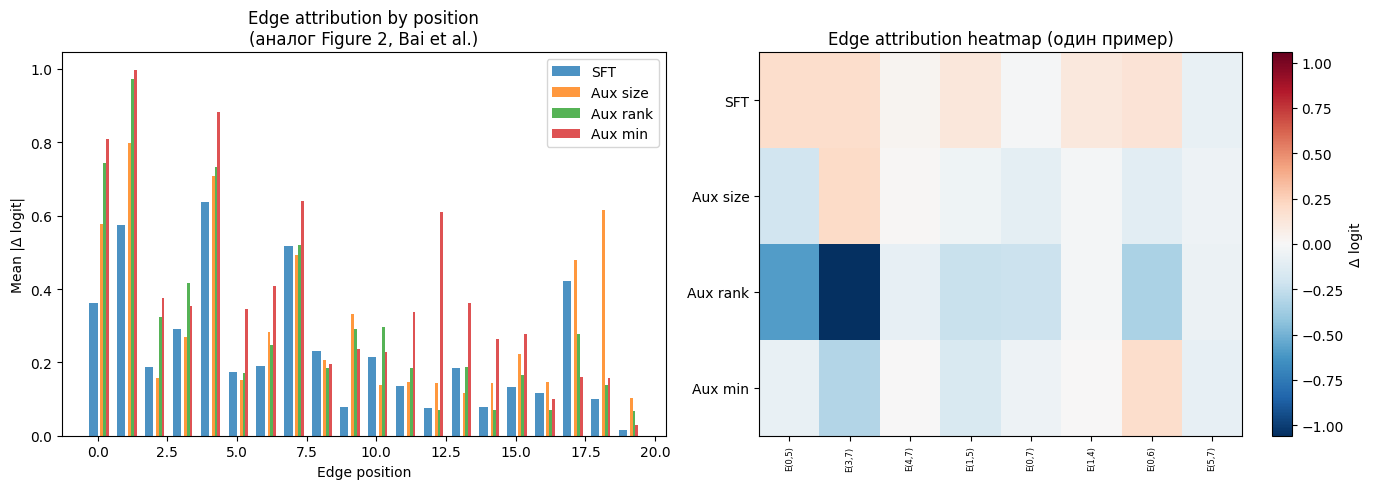

In [22]:
# Edge attribution by masking out each edge and measuring logit change

@torch.no_grad()
def edge_attribution(model, input_ids, ans_pos, target, num_edges):
    """Measure each edge's contribution by replacing it with <PAD>."""
    ids = input_ids.to(device)
    mask = (ids != PAD_ID)
    h, _ = model(ids, mask)
    base = model.classifier(h[0, ans_pos])[target].item()
    attrs = []
    for t in range(num_edges):
        m_ids = ids.clone()
        m_ids[0, t + 1] = PAD_ID
        h2, _ = model(m_ids, m_ids != PAD_ID)
        attrs.append(base - model.classifier(h2[0, ans_pos])[target].item())
    return attrs

N_EX = 20
attr_sft, attr_aux, edge_tok_labels = [], {"size": [], "rank": [], "min": []}, []

for batch in val_batches[:3]:
    for b in range(batch["input_ids"].size(0)):
        if len(attr_sft) >= N_EX:
            break
        m = batch["num_edges"][b].item()
        if not (5 <= m <= 20):
            continue
        ids = batch["input_ids"][b:b + 1]
        ap = batch["ans_pos"][b].item()
        tgt = batch["targets"][b].item()
        attr_sft.append(edge_attribution(sft_models[2], ids, ap, tgt, m))
        for DSU_type in ["size", "rank", "min"]:
            attr_aux[DSU_type].append(edge_attribution(aux_models[DSU_type], ids, ap, tgt, m))
        edge_tok_labels.append(
            [tokenizer.id2token.get(ids[0, t + 1].item(), "?") for t in range(m)])

# Average |attribution| by edge position
max_m = max(len(a) for a in attr_sft)
s_avg = np.zeros(max_m)
a_avg = {k: np.zeros(max_m) for k in ["size", "rank", "min"]}
cnt = np.zeros(max_m)
for i in range(len(attr_sft)):
    s = attr_sft[i]
    for t in range(len(s)):
        s_avg[t] += abs(s[t])
        for k in ["size", "rank", "min"]:
            a_avg[k][t] += abs(attr_aux[k][i][t])
        cnt[t] += 1
s_avg /= np.maximum(cnt, 1)
for k in ["size", "rank", "min"]:
    a_avg[k] /= np.maximum(cnt, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: avg attribution by position
v = cnt > 0
pos = np.arange(max_m)[v]
ax = axes[0]
ax.bar(pos - 0.15, s_avg[v], 0.3, label="SFT", color="C0", alpha=0.8)
for i, k in enumerate(["size", "rank", "min"]):
    ax.bar(pos + 0.15 + i*0.1, a_avg[k][v], 0.1, label=f"Aux {k}", color=f"C{i+1}", alpha=0.8)
ax.set_xlabel("Edge position")
ax.set_ylabel("Mean |Δ logit|")
ax.set_title("Edge attribution by position\n(аналог Figure 2, Bai et al.)")
ax.legend()

# Heatmap for one example
ax = axes[1]
d = np.array([attr_sft[0], attr_aux["size"][0], attr_aux["rank"][0], attr_aux["min"][0]])
lim = max(abs(d.min()), abs(d.max()))
im = ax.imshow(d, cmap="RdBu_r", aspect="auto", vmin=-lim, vmax=lim)
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(["SFT", "Aux size", "Aux rank", "Aux min"])
ax.set_xticks(range(len(edge_tok_labels[0])))
ax.set_xticklabels(edge_tok_labels[0], fontsize=6, rotation=90)
ax.set_title("Edge attribution heatmap (один пример)")
plt.colorbar(im, ax=ax, label="Δ logit")

plt.tight_layout()
plt.savefig("edge_attribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.6 Визуализация ошибок

Для обеих моделей собираем неправильно классифицированные графы и визуализируем их через `networkx`:
- **Вершины запроса** выделены цветом (красный = disconnected, зелёный = connected)
- **Кратчайший путь** между вершинами запроса (если существует) выделен зелёным
- Статистика ошибок: FP vs FN, размеры графов, количество рёбер

  100 errors
  size: 100 errors
  rank: 100 errors
  min: 73 errors


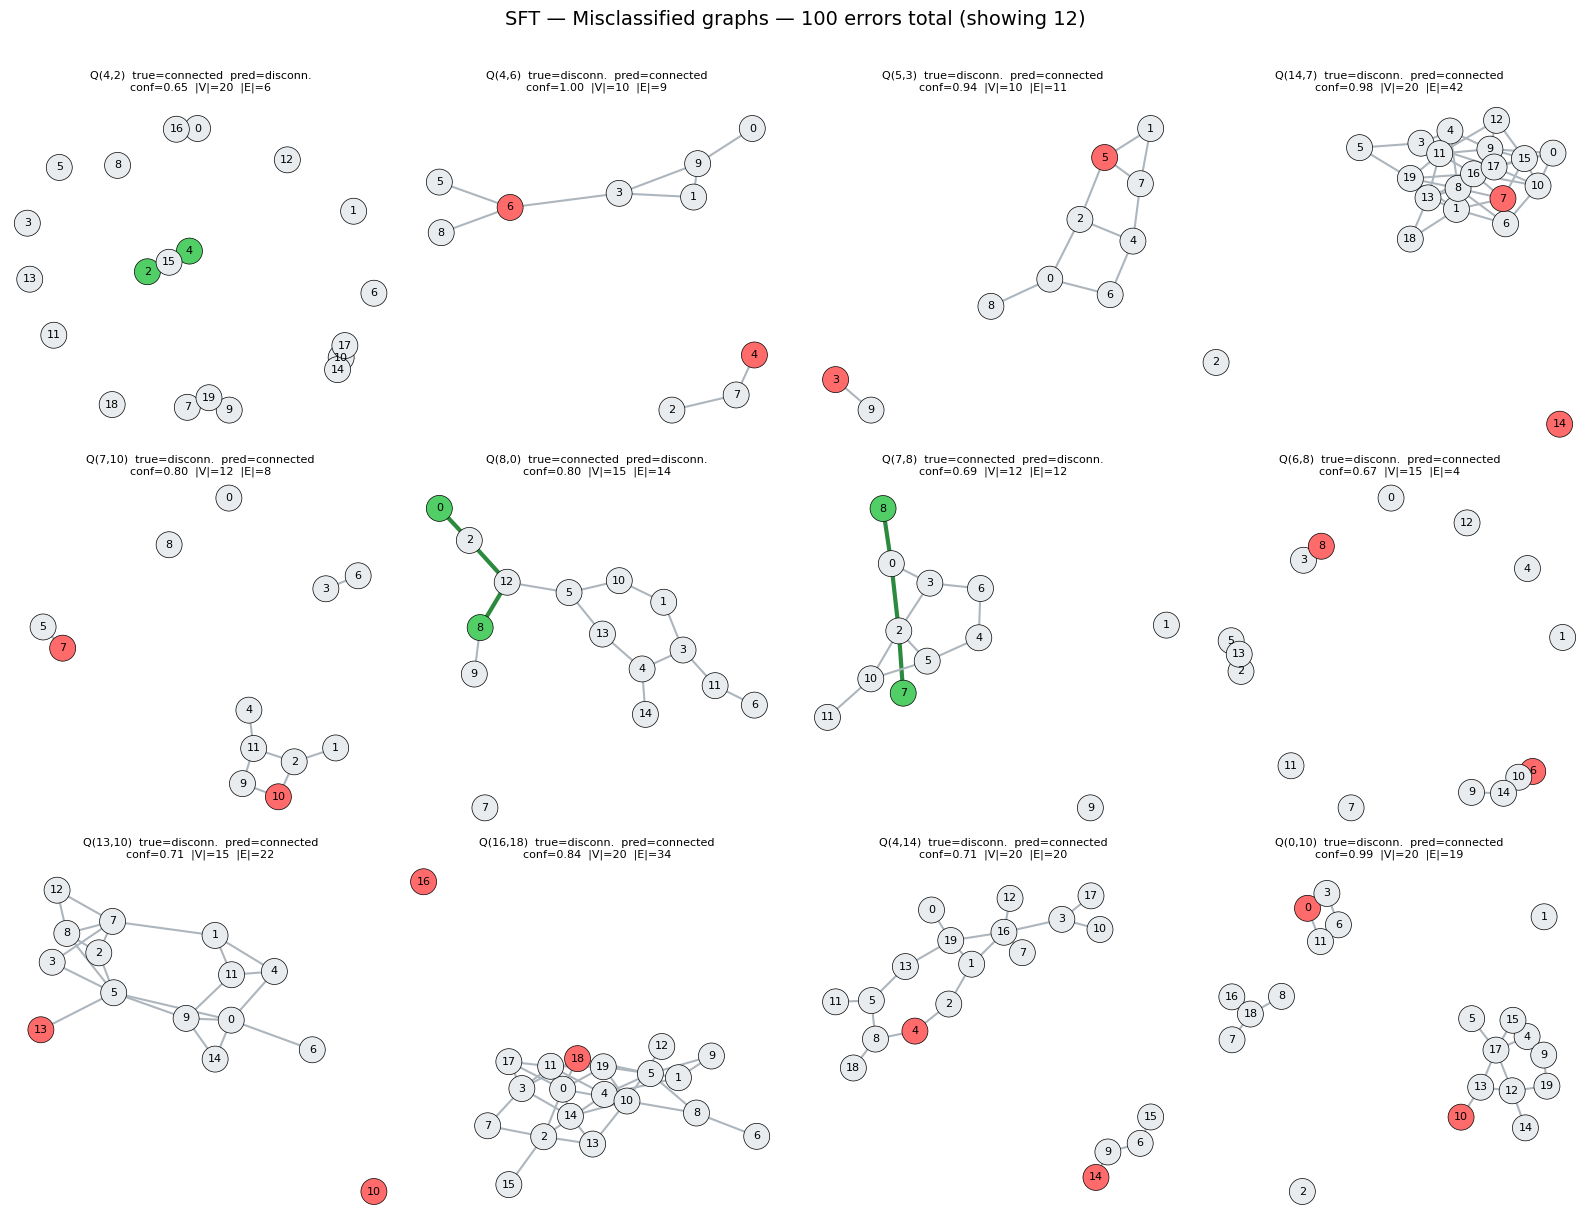

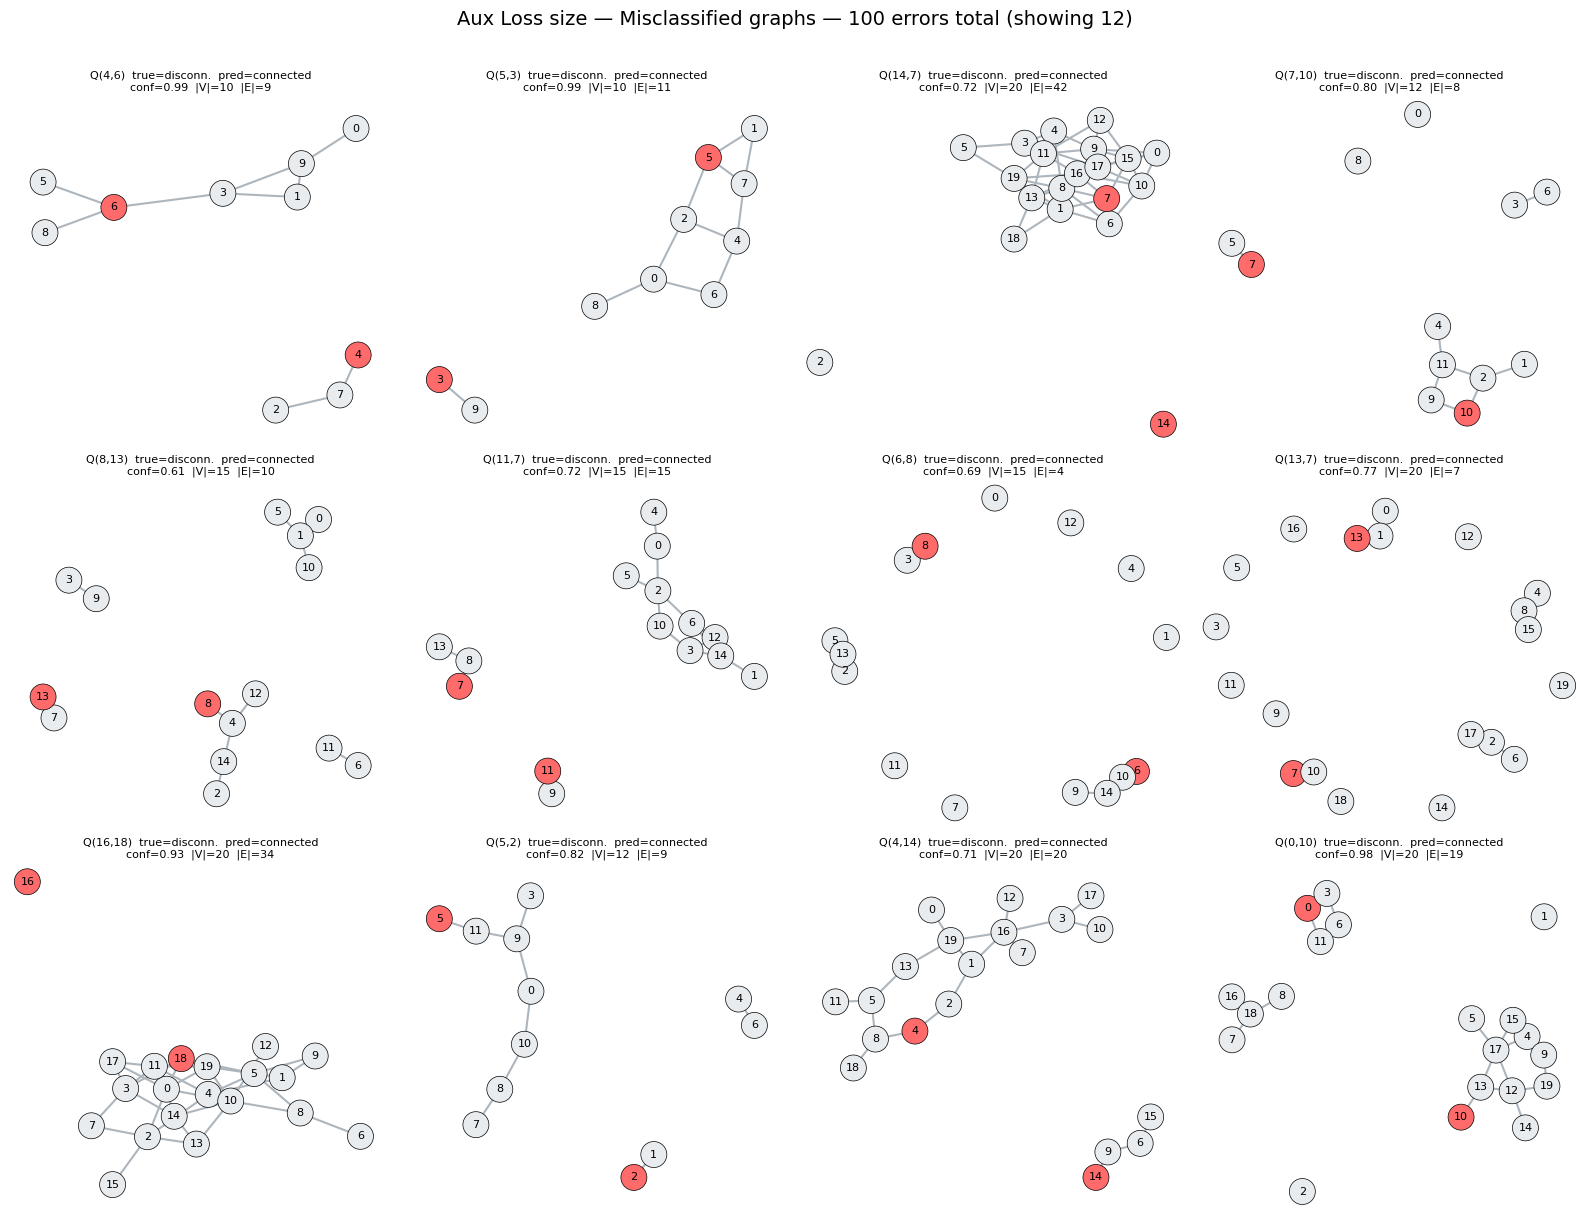

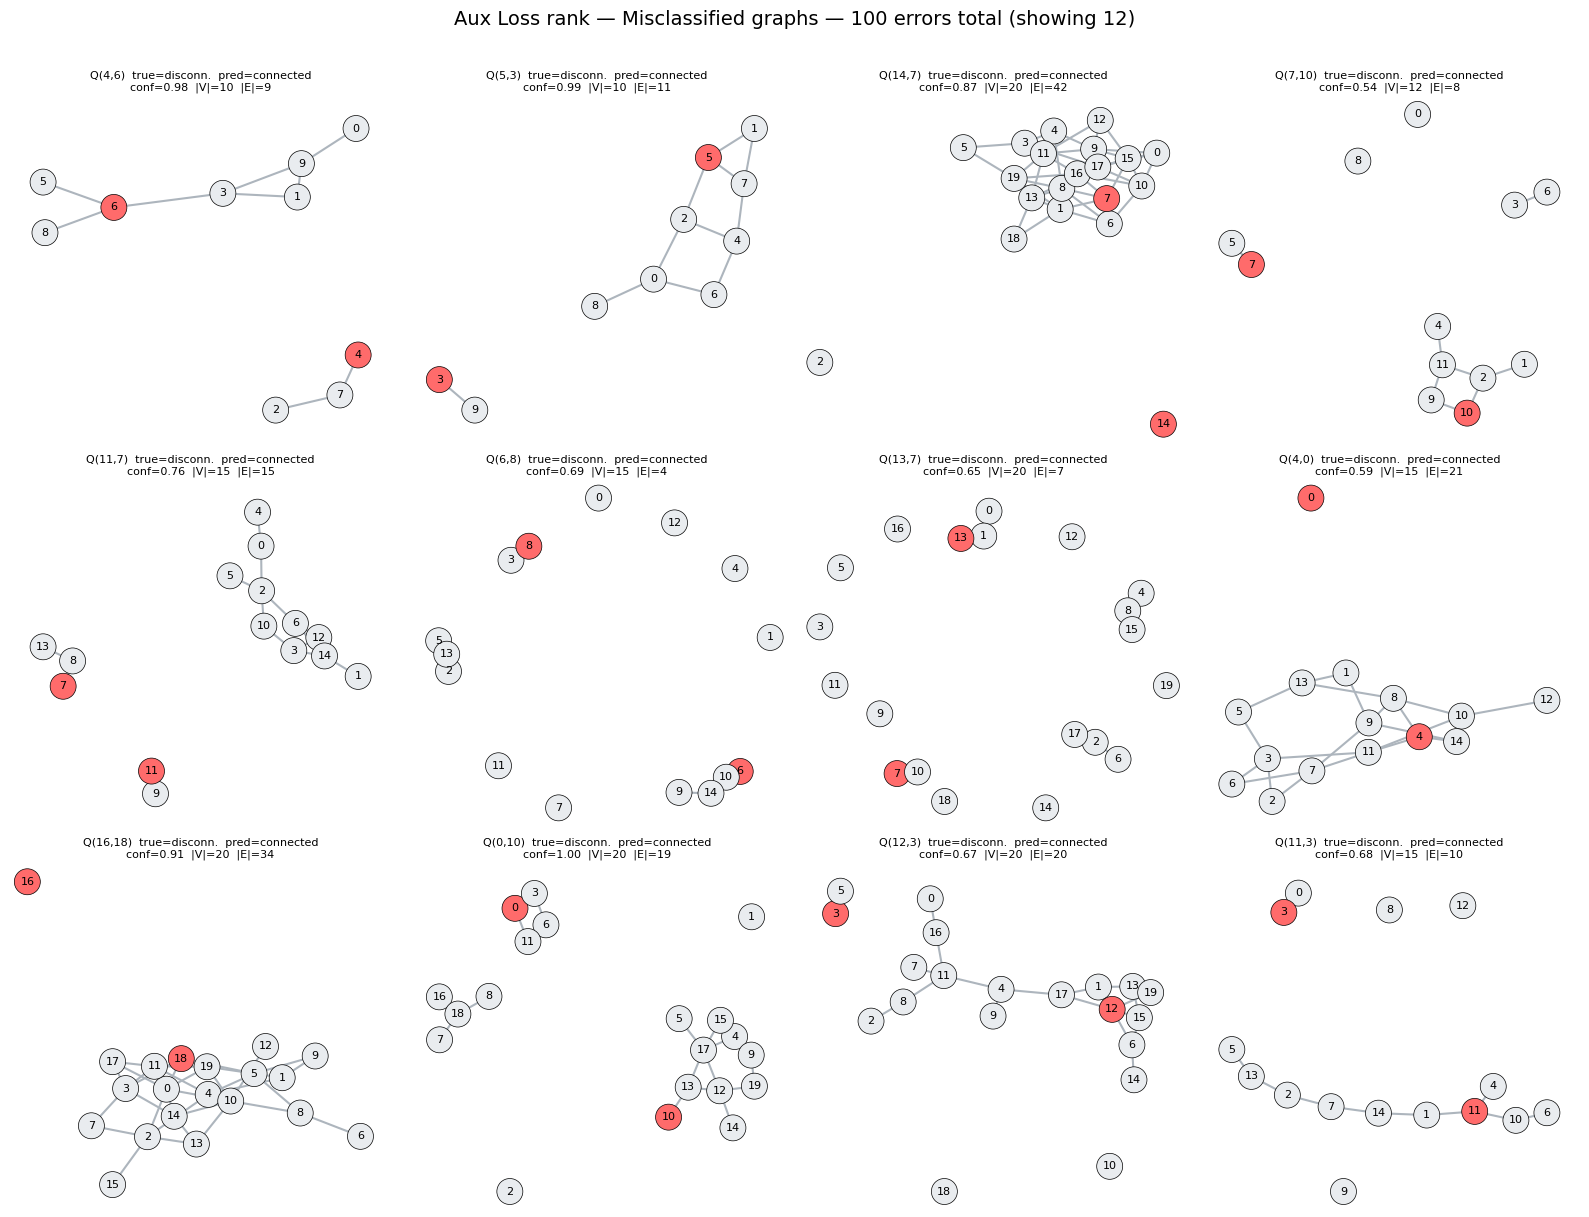

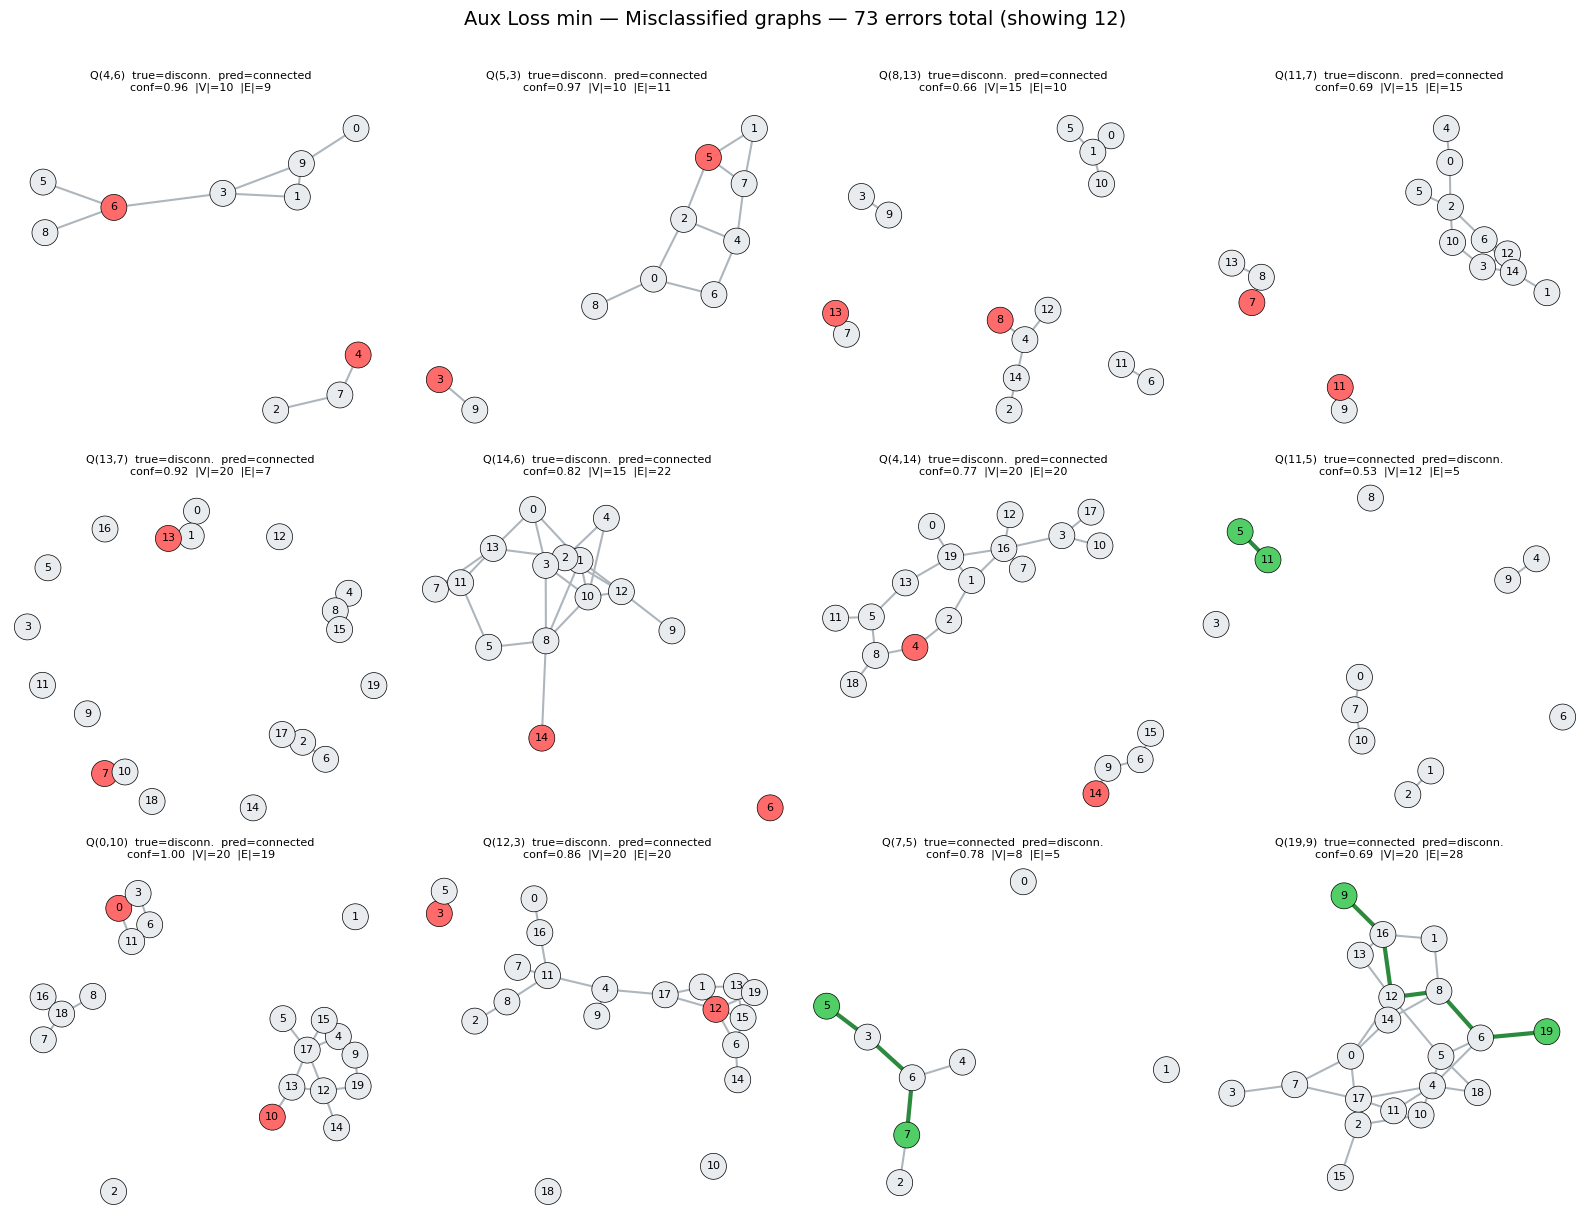


=== Error analysis ===

SFT (100 errors):
  False Positive (pred=connected, true=disconn.): 74
  False Negative (pred=disconn., true=connected):  26
  Graph sizes:  mean=15.3, range=[8, 20]
  Edge counts:  mean=14.6, range=[2, 42]

Aux size (100 errors):
  False Positive (pred=connected, true=disconn.): 90
  False Negative (pred=disconn., true=connected):  10
  Graph sizes:  mean=15.2, range=[8, 20]
  Edge counts:  mean=14.5, range=[2, 42]

Aux rank (100 errors):
  False Positive (pred=connected, true=disconn.): 83
  False Negative (pred=disconn., true=connected):  17
  Graph sizes:  mean=14.9, range=[8, 20]
  Edge counts:  mean=14.4, range=[3, 42]

Aux min (73 errors):
  False Positive (pred=connected, true=disconn.): 49
  False Negative (pred=disconn., true=connected):  24
  Graph sizes:  mean=15.4, range=[8, 20]
  Edge counts:  mean=14.0, range=[3, 40]


In [23]:
import networkx as nx

# ── Collect misclassified examples ──

@torch.no_grad()
def collect_errors(model, loader, device, max_errors=100):
    """Run inference and collect misclassified examples."""
    model.eval()
    errors = []
    for batch in loader:
        ids = batch["input_ids"].to(device)
        hidden, _ = model(ids, ids != PAD_ID)
        B = ids.size(0)
        for b in range(B):
            ap = batch["ans_pos"][b].item()
            logits = model.classifier(hidden[b, ap])
            pred = logits.argmax().item()
            true = batch["targets"][b].item()
            if pred != true:
                m = batch["num_edges"][b].item()
                n = int(batch["vertex_mask"][b].sum().item())
                toks = ids[b].cpu().tolist()

                edges = []
                for t in range(1, m + 1):
                    tok = tokenizer.id2token.get(toks[t], "")
                    if tok.startswith("E("):
                        i, j = tok[2:-1].split(",")
                        edges.append((int(i), int(j)))

                q_tok = tokenizer.id2token.get(toks[m + 2], "")
                if q_tok.startswith("Q("):
                    qi, qj = q_tok[2:-1].split(",")
                    query = (int(qi), int(qj))
                else:
                    query = (0, 1)

                probs = torch.softmax(logits, 0)
                errors.append(dict(
                    edges=edges, query=query, n=n,
                    true_label=true, pred_label=pred,
                    confidence=probs[pred].item(),
                    graph_type=batch.get("type", "unknown"),
                ))
                if len(errors) >= max_errors:
                    return errors
    return errors


def draw_error_graph(err, ax):
    """Draw a single misclassified graph with highlighted query and path."""
    G = nx.Graph()
    G.add_nodes_from(range(err["n"]))
    G.add_edges_from(err["edges"])
    u, v = err["query"]

    # Find shortest path (if connected)
    path_edges = set()
    if err["true_label"] == 1 and nx.has_path(G, u, v):
        path = nx.shortest_path(G, u, v)
        path_edges = {(path[i], path[i + 1]) for i in range(len(path) - 1)}

    # Node colors: query vertices highlighted
    node_colors = []
    for node in G.nodes():
        if node in (u, v):
            node_colors.append("#FF6B6B" if err["true_label"] == 0 else "#51CF66")
        else:
            node_colors.append("#E9ECEF")

    # Edge colors: path highlighted
    edge_colors = []
    edge_widths = []
    for e in G.edges():
        if (e[0], e[1]) in path_edges or (e[1], e[0]) in path_edges:
            edge_colors.append("#2B8A3E")
            edge_widths.append(3.0)
        else:
            edge_colors.append("#ADB5BD")
            edge_widths.append(1.5)

    pos = nx.spring_layout(G, seed=42, k=1.5 / max(err["n"] ** 0.5, 1))
    nx.draw(G, pos, ax=ax, with_labels=True, node_size=350, font_size=8,
            node_color=node_colors, edge_color=edge_colors, width=edge_widths,
            edgecolors="black", linewidths=0.5)

    true_s = "connected" if err["true_label"] else "disconn."
    pred_s = "connected" if err["pred_label"] else "disconn."
    ax.set_title(f"Q({u},{v})  true={true_s}  pred={pred_s}\n"
                 f"conf={err['confidence']:.2f}  |V|={err['n']}  |E|={len(err['edges'])}",
                 fontsize=8)


# ── Collect errors for both models ──
val_loader_full = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)

print("Collecting SFT errors...")
sft_errors = collect_errors(sft_models[2], val_loader_full, device)
print(f"  {len(sft_errors)} errors")

print("Collecting Aux errors...")
aux_errors = {}
for DSU_type in ["size", "rank", "min"]:
    aux_errors[DSU_type] = collect_errors(aux_models[DSU_type], val_loader_full, device)
    print(f"  {DSU_type}: {len(aux_errors[DSU_type])} errors")


# ── Plot errors ──
def plot_errors(errors, title, n_show=12):
    cols = 4
    rows = min((n_show + cols - 1) // cols, (len(errors) + cols - 1) // cols)
    n_show = min(n_show, len(errors))
    if n_show == 0:
        print(f"  {title}: no errors!")
        return

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for i in range(n_show):
        draw_error_graph(errors[i], axes[i])
    for i in range(n_show, len(axes)):
        axes[i].axis("off")

    fig.suptitle(f"{title} — {len(errors)} errors total (showing {n_show})",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    return fig


fig_sft = plot_errors(sft_errors, "SFT — Misclassified graphs")
if fig_sft:
    fig_sft.savefig("errors_sft.png", dpi=150, bbox_inches="tight")

for DSU_type in ["size", "rank", "min"]:
    fig_aux = plot_errors(aux_errors[DSU_type], f"Aux Loss {DSU_type} — Misclassified graphs")
    if fig_aux:
        fig_aux.savefig(f"errors_aux_{DSU_type}.png", dpi=150, bbox_inches="tight")

plt.show()

# ── Statistics ──
print("\n=== Error analysis ===")
for name, errors in [("SFT", sft_errors)] + [(f"Aux {t}", aux_errors[t]) for t in ["size", "rank", "min"]]:
    if not errors:
        print(f"{name}: no errors")
        continue
    fp = sum(1 for e in errors if e["true_label"] == 0 and e["pred_label"] == 1)
    fn = sum(1 for e in errors if e["true_label"] == 1 and e["pred_label"] == 0)
    sizes = [e["n"] for e in errors]
    n_edges = [len(e["edges"]) for e in errors]
    print(f"\n{name} ({len(errors)} errors):")
    print(f"  False Positive (pred=connected, true=disconn.): {fp}")
    print(f"  False Negative (pred=disconn., true=connected):  {fn}")
    print(f"  Graph sizes:  mean={np.mean(sizes):.1f}, range=[{min(sizes)}, {max(sizes)}]")
    print(f"  Edge counts:  mean={np.mean(n_edges):.1f}, range=[{min(n_edges)}, {max(n_edges)}]")

## 7. Сохранение чекпоинтов (Google Drive)

In [24]:
# Раскомментируй для сохранения на Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# !cp -r checkpoints /content/drive/MyDrive/diplom_graph_checkpoints/
# !cp training_curves.png /content/drive/MyDrive/diplom_graph_checkpoints/

## 8. Capacity Ablation for `size_DSU` and `rank_DSU`

Проверяем гипотезу, что слабые результаты `size_DSU` и `rank_DSU` связаны не с самим target, а с недостаточной мощностью `2L` auxiliary-модели.

Ниже:
1. обучаем более глубокие auxiliary-модели для `size` и `rank`;
2. сравниваем их с уже обученными `2L` версиями;
3. строим графики и по финальной accuracy, и по точности предсказания самого DSU state на разных позициях ребра.

Первая рекомендация — начать с depth-only ablation (`4L`, `6L`) при том же `d_model=256`, чтобы изолировать эффект мощности модели от изменения самого auxiliary target.

In [3]:
from pathlib import Path


def aux_spec(label, dsu_mode, n_layer, d_model, n_head, save_dir, batch_size, epochs=50, patience=10, lambda_state=10.0):
    return {
        "label": label,
        "dsu_mode": dsu_mode,
        "n_layer": n_layer,
        "d_model": d_model,
        "n_head": n_head,
        "lambda_state": lambda_state,
        "batch_size": batch_size,
        "epochs": epochs,
        "patience": patience,
        "save_dir": save_dir,
        "checkpoint": f"{save_dir}/checkpoint_best.pt",
    }


LARGER_AUX_RUNS = [
    # aux_spec("Aux size 4L d256", "size", 4, 256, 4, "checkpoints/graph_aux_4L_size", batch_size=32),
    # aux_spec("Aux size 6L d256", "size", 6, 256, 4, "checkpoints/graph_aux_6L_size", batch_size=24),
    # aux_spec("Aux rank 4L d256", "rank", 4, 256, 4, "checkpoints/graph_aux_4L_rank", batch_size=32),
    # aux_spec("Aux rank 6L d256", "rank", 6, 256, 4, "checkpoints/graph_aux_6L_rank", batch_size=24),
    aux_spec("Aux rank 10L d256", "rank", 10, 256, 4, "checkpoints/graph_aux_10L_rank", batch_size=24)
    aux_spec("Aux size 10L d256", "size", 10, 256, 4, "checkpoints/graph_aux_10L_size", batch_size=24)

]

# Optional wider runs: add after the depth-only ablation if needed.
# LARGER_AUX_RUNS += [
#     aux_spec("Aux size 4L d384", "size", 4, 384, 6, "checkpoints/graph_aux_4L_d384_size", batch_size=16),
#     aux_spec("Aux rank 4L d384", "rank", 4, 384, 6, "checkpoints/graph_aux_4L_d384_rank", batch_size=16),
# ]

for cfg in LARGER_AUX_RUNS:
    # ckpt = Path(cfg["checkpoint"])
    # if ckpt.exists():
    #     print(f"Skip {cfg['label']}: {ckpt} already exists")
    #     continue

    label = cfg["label"]
    dsu_mode = cfg["dsu_mode"]
    n_layer = cfg["n_layer"]
    d_model = cfg["d_model"]
    n_head = cfg["n_head"]
    lambda_state = cfg["lambda_state"]
    batch_size = cfg["batch_size"]
    epochs = cfg["epochs"]
    patience = cfg["patience"]
    save_dir = cfg["save_dir"]

    print(f"\n{'=' * 80}")
    print(f"Training {label}")
    print(f"{'=' * 80}")

    !python -m graph_connectivity.src.train \
        --train_path graph_connectivity/data/train.json \
        --val_path graph_connectivity/data/val.json \
        --max_n 30 \
        --d_model {d_model} --n_layer {n_layer} --n_head {n_head} \
        --lr 5e-5 --weight_decay 0.01 \
        --batch_size {batch_size} --epochs {epochs} --patience {patience} \
        --lambda_state {lambda_state} \
        --dsu_mode {dsu_mode} \
        --save_dir {save_dir} \
        --seed 42


Training Aux size 10L d256
Device: cuda
Vocab size: 1312
Train: 43000 graphs, Val: 2000 graphs
Model parameters: 8,267,266
Probe parameters: 234,000
Epoch   0 | train loss=20.4327 acc=0.7839 | val loss=17.8384 acc=0.7765 | 64.6s 
Epoch   1 | train loss=16.9709 acc=0.7846 | val loss=16.0429 acc=0.7735 | 64.6s 
Epoch   2 | train loss=15.4433 acc=0.7855 | val loss=14.9404 acc=0.7815 | 64.2s 
Epoch   3 | train loss=14.3024 acc=0.7874 | val loss=13.8343 acc=0.7710 | 63.7s 
Epoch   4 | train loss=13.4242 acc=0.7936 | val loss=13.0805 acc=0.7850 | 63.9s 
Epoch   5 | train loss=12.6784 acc=0.8124 | val loss=12.5691 acc=0.8165 | 64.2s 
Epoch   6 | train loss=12.1027 acc=0.8375 | val loss=11.7910 acc=0.8515 | 64.4s 
Epoch   7 | train loss=11.5770 acc=0.8563 | val loss=11.3411 acc=0.8695 | 64.0s 
Epoch   8 | train loss=11.1141 acc=0.8689 | val loss=10.9296 acc=0.8765 | 64.0s 
Epoch   9 | train loss=10.6187 acc=0.8786 | val loss=10.4291 acc=0.8730 | 64.2s 
Epoch  10 | train loss=10.2699 acc=0.883

In [8]:
import pandas as pd
import torch
from torch.utils.data import DataLoader
from graph_connectivity.src.data import GraphConnectivityDataset, collate_fn
from graph_connectivity.src.evaluate import evaluate_dataset, load_checkpoint
from graph_connectivity.src.tokenizer import GraphTokenizer

BASE_AUX_SPECS = [
    aux_spec("Aux size 2L d256", "size", 2, 256, 4, "checkpoints/graph_aux_2L_size", batch_size=32),
    aux_spec("Aux rank 2L d256", "rank", 2, 256, 4, "checkpoints/graph_aux_2L_rank", batch_size=32),
    aux_spec("Aux min 2L d256", "min", 2, 256, 4, "checkpoints/graph_aux_2L_min", batch_size=32),
]
LARGER_AUX_RUNS = [
    aux_spec("Aux size 4L d256", "size", 4, 256, 4, "checkpoints/graph_aux_4L_size", batch_size=32),
    aux_spec("Aux size 6L d256", "size", 6, 256, 4, "checkpoints/graph_aux_6L_size", batch_size=24),
    aux_spec("Aux rank 4L d256", "rank", 4, 256, 4, "checkpoints/graph_aux_4L_rank", batch_size=32),
    aux_spec("Aux rank 6L d256", "rank", 6, 256, 4, "checkpoints/graph_aux_6L_rank", batch_size=24),
    aux_spec("Aux rank 10L d256", "rank", 10, 256, 4, "checkpoints/graph_aux_10L_rank", batch_size=24),
    aux_spec("Aux size 10L d256", "size", 10, 256, 4, "checkpoints/graph_aux_10L_size", batch_size=24)

]

CAPACITY_SPECS = BASE_AUX_SPECS + LARGER_AUX_RUNS

capacity_eval = {}
capacity_rows = []
capacity_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
capacity_tokenizer = GraphTokenizer(max_n=30)


def evaluate_aux_spec(spec, split_names=None):
    split_names = split_names or [
        "test_id",
        "test_ood_large_n",
        "test_ood_cyclic_grid",
        "test_ood_adversarial",
        "test_ood_2chain",
        "test_ood_2clique",
    ]
    model, probe = load_checkpoint(
        spec["checkpoint"],
        capacity_tokenizer,
        capacity_device,
        d_model=spec["d_model"],
        n_layer=spec["n_layer"],
        n_head=spec["n_head"],
        max_n=30,
    )

    results = {}
    for split_name in split_names:
        ds = GraphConnectivityDataset(
            f"graph_connectivity/data/{split_name}.json",
            capacity_tokenizer,
            max_n=30,
            fixed=True,
            dsu_mode=spec["dsu_mode"],
        )
        loader = DataLoader(
            ds, batch_size=64, shuffle=False, collate_fn=collate_fn, num_workers=0
        )
        results[split_name] = evaluate_dataset(
            model,
            probe,
            loader,
            spec["lambda_state"],
            capacity_device,
        )
    return results


for spec in CAPACITY_SPECS:
    ckpt = Path(spec["checkpoint"])
    if not ckpt.exists():
        print(f"Skip {spec['label']}: {ckpt} not found")
        continue

    print(f"\n{'=' * 80}")
    print(spec["label"])
    print(f"{'=' * 80}")
    results = evaluate_aux_spec(spec)
    capacity_eval[spec["label"]] = results

    for split_name, metrics in results.items():
        print(
            f"{split_name}: acc={metrics['accuracy']:.4f} | "
            f"loss={metrics['loss']:.4f} | state_loss={metrics['loss_state']:.4f}"
        )

    capacity_rows.append({
        "Model": spec["label"],
        "Target": spec["dsu_mode"],
        "Layers": spec["n_layer"],
        "d_model": spec["d_model"],
        "Heads": spec["n_head"],
        "ID": results["test_id"]["accuracy"],
        "Large N": results["test_ood_large_n"]["accuracy"],
        "Cyclic Grid": results["test_ood_cyclic_grid"]["accuracy"],
        "Adv. Degree": results["test_ood_adversarial"]["accuracy"],
        "2-Chain": results["test_ood_2chain"]["accuracy"],
        "2-Clique": results["test_ood_2clique"]["accuracy"],
    })

capacity_df = pd.DataFrame(capacity_rows).sort_values(["Target", "Layers", "d_model"]).reset_index(drop=True)
display(
    capacity_df.style.format({
        "ID": "{:.1%}",
        "Large N": "{:.1%}",
        "Cyclic Grid": "{:.1%}",
        "Adv. Degree": "{:.1%}",
        "2-Chain": "{:.1%}",
        "2-Clique": "{:.1%}",
    })
)


Aux size 2L d256
test_id: acc=0.9440 | loss=8.7001 | state_loss=0.8554
test_ood_large_n: acc=0.7210 | loss=31.6814 | state_loss=3.0776
test_ood_cyclic_grid: acc=1.0000 | loss=22.1965 | state_loss=2.2188
test_ood_adversarial: acc=0.5600 | loss=9.1956 | state_loss=0.8401
test_ood_2chain: acc=0.5120 | loss=20.9104 | state_loss=1.8227
test_ood_2clique: acc=0.4700 | loss=18.5911 | state_loss=1.6439

Aux rank 2L d256
test_id: acc=0.9462 | loss=8.7705 | state_loss=0.8629
test_ood_large_n: acc=0.7210 | loss=31.5072 | state_loss=3.0616
test_ood_cyclic_grid: acc=1.0000 | loss=21.4333 | state_loss=2.1425
test_ood_adversarial: acc=0.5840 | loss=8.7259 | state_loss=0.7851
test_ood_2chain: acc=0.5200 | loss=18.4212 | state_loss=1.6709
test_ood_2clique: acc=0.4760 | loss=19.0448 | state_loss=1.6051

Aux min 2L d256
test_id: acc=0.9636 | loss=2.2229 | state_loss=0.2126
test_ood_large_n: acc=0.7260 | loss=28.0134 | state_loss=2.6449
test_ood_cyclic_grid: acc=1.0000 | loss=14.8091 | state_loss=1.4806
t

,Model,Target,Layers,d_model,Heads,ID,Large N,Cyclic Grid,Adv. Degree,2-Chain,2-Clique
0,Aux min 2L d256,min,2,256,4,96.4%,72.6%,100.0%,68.9%,52.4%,48.4%
1,Aux rank 2L d256,rank,2,256,4,94.6%,72.1%,100.0%,58.4%,52.0%,47.6%
2,Aux rank 4L d256,rank,4,256,4,93.7%,72.2%,100.0%,58.5%,51.3%,47.6%
3,Aux rank 6L d256,rank,6,256,4,94.7%,73.0%,100.0%,61.4%,51.2%,47.6%
4,Aux rank 10L d256,rank,10,256,4,94.9%,73.7%,100.0%,62.6%,51.1%,47.7%
5,Aux size 2L d256,size,2,256,4,94.4%,72.1%,100.0%,56.0%,51.2%,47.0%
6,Aux size 4L d256,size,4,256,4,94.6%,72.1%,100.0%,55.0%,51.4%,47.6%
7,Aux size 6L d256,size,6,256,4,95.2%,73.5%,100.0%,60.0%,51.5%,47.6%
8,Aux size 10L d256,size,10,256,4,95.0%,74.6%,100.0%,62.1%,51.6%,47.6%


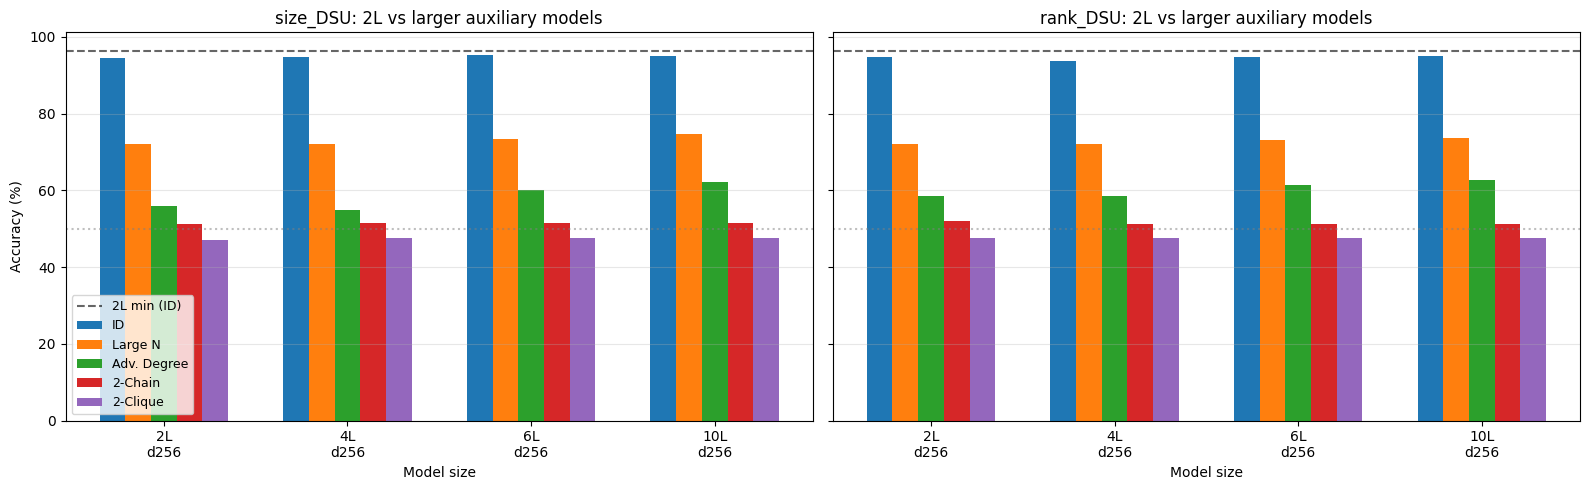

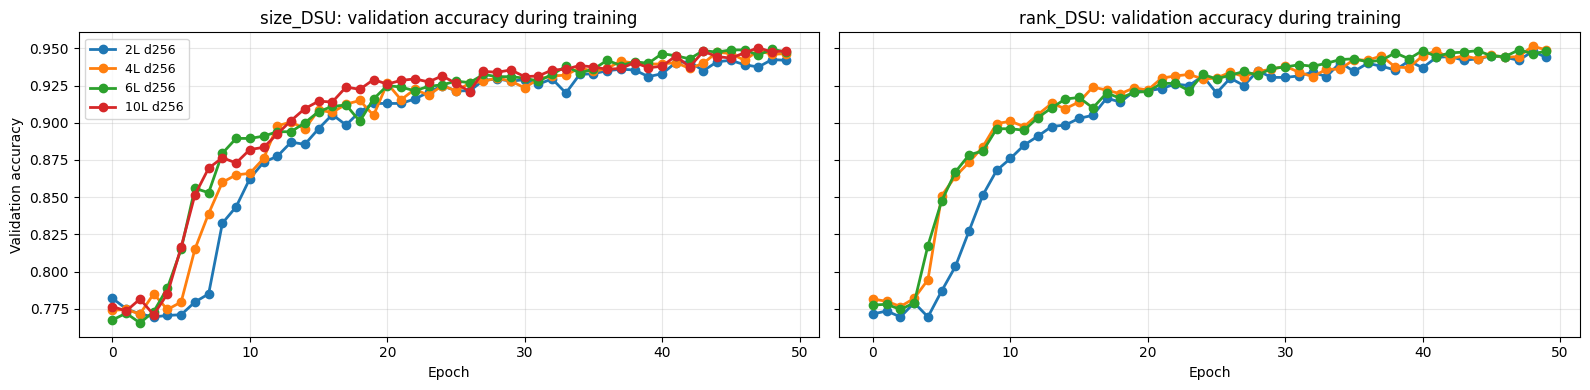

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt

PLOT_SPLITS = [
    ("ID", "ID"),
    ("Large N", "Large N"),
    ("Adv. Degree", "Adv. Degree"),
    ("2-Chain", "2-Chain"),
    ("2-Clique", "2-Clique"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, mode in zip(axes, ["size", "rank"]):
    sub = (
        capacity_df[capacity_df["Target"] == mode]
        .sort_values(["Layers", "d_model"])
        .reset_index(drop=True)
    )
    labels = [f"{int(row.Layers)}L\nd{int(row.d_model)}" for row in sub.itertuples()]
    x = np.arange(len(labels))
    width = 0.14

    for i, (col, legend_label) in enumerate(PLOT_SPLITS):
        vals = sub[col].to_numpy() * 100
        ax.bar(
            x + (i - (len(PLOT_SPLITS) - 1) / 2) * width,
            vals,
            width=width,
            label=legend_label,
        )

    if "Aux min 2L d256" in capacity_eval:
        ref = capacity_eval["Aux min 2L d256"]["test_id"]["accuracy"] * 100
        ax.axhline(
            ref,
            color="black",
            linestyle="--",
            alpha=0.6,
            label="2L min (ID)" if mode == "size" else None,
        )

    ax.set_title(f"{mode}_DSU: 2L vs larger auxiliary models")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel("Model size")
    ax.grid(True, axis="y", alpha=0.3)
    ax.axhline(50, color="gray", linestyle=":", alpha=0.5)

axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.savefig("capacity_ablation_size_rank_accuracy.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
for ax, mode in zip(axes, ["size", "rank"]):
    specs = [
        spec for spec in CAPACITY_SPECS
        if spec["dsu_mode"] == mode and Path(spec["checkpoint"]).exists()
    ]
    specs = sorted(specs, key=lambda spec: (spec["n_layer"], spec["d_model"]))

    for spec in specs:
        log_path = Path(spec["save_dir"]) / "train_log.json"
        if not log_path.exists():
            continue
        with open(log_path) as f:
            log = json.load(f)
        epochs = [entry["epoch"] for entry in log]
        val_acc = [entry["val"]["accuracy"] for entry in log]
        ax.plot(
            epochs,
            val_acc,
            marker="o",
            linewidth=2,
            label=f"{spec['n_layer']}L d{spec['d_model']}",
        )

    ax.set_title(f"{mode}_DSU: validation accuracy during training")
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Validation accuracy")
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.savefig("capacity_ablation_size_rank_val_curves.png", dpi=150)
plt.show()

Aux size 2L d256: first10=0.815 | edges10_19=0.529
Aux size 4L d256: first10=0.886 | edges10_19=0.716
Aux size 6L d256: first10=0.909 | edges10_19=0.757
Aux size 10L d256: first10=0.913 | edges10_19=0.799
Aux rank 2L d256: first10=0.844 | edges10_19=0.560
Aux rank 4L d256: first10=0.842 | edges10_19=0.574
Aux rank 6L d256: first10=0.905 | edges10_19=0.761
Aux rank 10L d256: first10=0.903 | edges10_19=0.765


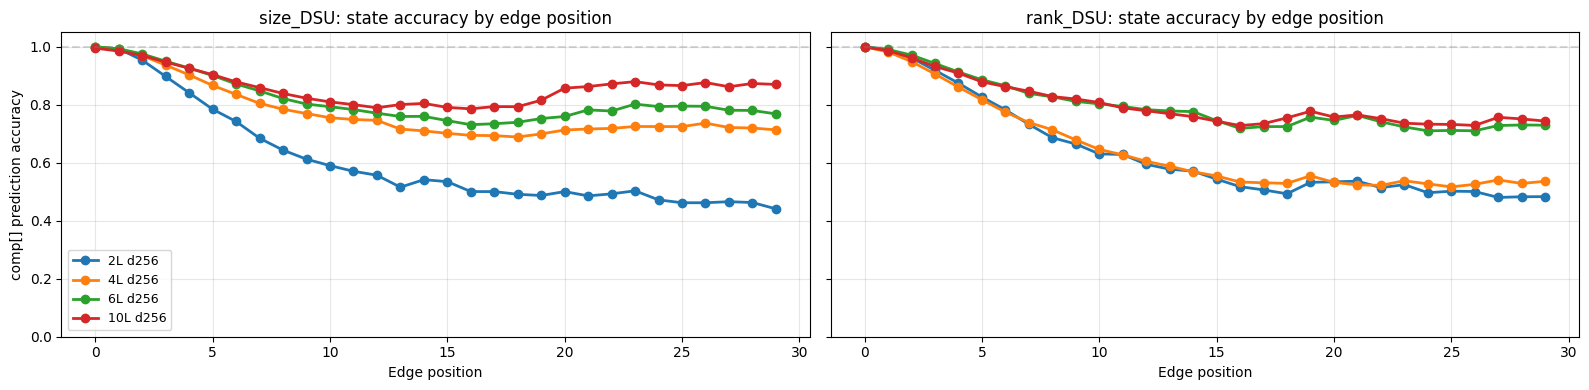

In [10]:
from graph_connectivity.src.evaluate import load_checkpoint
from graph_connectivity.src.tokenizer import PAD_ID


@torch.no_grad()
def per_position_accuracy_for_spec(spec, n_batches=8):
    ds = GraphConnectivityDataset(
        "graph_connectivity/data/val.json",
        capacity_tokenizer,
        max_n=30,
        fixed=True,
        dsu_mode=spec["dsu_mode"],
    )
    loader = DataLoader(
        ds, batch_size=64, shuffle=False, collate_fn=collate_fn, num_workers=0
    )
    model, probe = load_checkpoint(
        spec["checkpoint"],
        capacity_tokenizer,
        capacity_device,
        d_model=spec["d_model"],
        n_layer=spec["n_layer"],
        n_head=spec["n_head"],
        max_n=30,
    )

    if probe is None:
        raise ValueError(f"Probe is missing for {spec['label']}")

    pos_correct = {}
    pos_total = {}
    for batch_idx, batch in enumerate(loader):
        if batch_idx >= n_batches:
            break

        input_ids = batch["input_ids"].to(capacity_device)
        attn_mask = input_ids != PAD_ID
        _, last_head_outputs = model(input_ids, attn_mask)

        comp_states = batch["comp_states"].to(capacity_device)
        vertex_mask = batch["vertex_mask"].to(capacity_device)
        num_edges = comp_states.size(1)
        edge_positions = torch.arange(1, num_edges + 1, device=capacity_device)

        edge_head_outputs = last_head_outputs[:, :, edge_positions, :]
        logits = probe(edge_head_outputs).mean(dim=1)
        preds = logits.argmax(dim=-1)

        for b in range(input_ids.size(0)):
            m = batch["num_edges"][b].item()
            n_vertices = int(vertex_mask[b].sum().item())
            for t in range(m):
                correct = (preds[b, t, :n_vertices] == comp_states[b, t, :n_vertices]).sum().item()
                pos_correct[t] = pos_correct.get(t, 0) + correct
                pos_total[t] = pos_total.get(t, 0) + n_vertices

    positions = sorted(pos_correct)
    accuracies = [pos_correct[t] / pos_total[t] for t in positions]
    return positions, accuracies


fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
for ax, mode in zip(axes, ["size", "rank"]):
    specs = [
        spec for spec in CAPACITY_SPECS
        if spec["dsu_mode"] == mode and Path(spec["checkpoint"]).exists()
    ]
    specs = sorted(specs, key=lambda spec: (spec["n_layer"], spec["d_model"]))

    for spec in specs:
        positions, accuracies = per_position_accuracy_for_spec(spec, n_batches=8)
        ax.plot(
            positions[:30],
            accuracies[:30],
            marker="o",
            linewidth=2,
            label=f"{spec['n_layer']}L d{spec['d_model']}",
        )
        head10 = np.mean(accuracies[:10]) if accuracies else float("nan")
        tail10 = np.mean(accuracies[10:20]) if len(accuracies) > 10 else float("nan")
        print(f"{spec['label']}: first10={head10:.3f} | edges10_19={tail10:.3f}")

    ax.set_title(f"{mode}_DSU: state accuracy by edge position")
    ax.set_xlabel("Edge position")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color="gray", linestyle="--", alpha=0.3)

axes[0].set_ylabel("comp[] prediction accuracy")
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.savefig("capacity_ablation_size_rank_per_position.png", dpi=150)
plt.show()